# Авито Подработка

Бинарная классификация: выйдет ли пользователь на смену?

Метрика: ROC-AUC с ограничением по FPR (топ-кандидаты на смену).

In [2]:
!pip install lightgbm catboost xgboost psutil -q


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [3]:
DATA_DIR = '/Users/a-ataman/Desktop/Hackathon/'

In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

users  = pd.read_csv(DATA_DIR + 'user.csv')
shifts = pd.read_csv(DATA_DIR + 'shift.csv')
events = pd.read_csv(DATA_DIR + 'event.csv')

users.shape, shifts.shape, events.shape

((5154, 4), (39999, 11), (383883, 5))

## Данные

In [5]:
users.head(3)

,location_id,is_strict_location,id,has_mk
0,64,False,0a66722f9259c08a6a6d78d2ea90e375,True
1,61,False,314a2bc9a488ba22a31ad0d9a0c1c26f,True
2,181,False,73f5bbba685e5e676f59a4709f04c825,True


In [6]:
shifts.head(3)

,id,start_at,location_id,task_type,employer_id,workplace_id,need_mk,id_differential,hours,reward,capacity
0,9857,2026-01-06 12:30:00+00:00,161,Погрузка и разгрузка товара,c1714b6178cdbe470384bdd7ea181f3c,27b794bbdb945cc982c40394dc9b520a,False,False,3,900.0,2
1,21761,2026-01-15 12:30:00+00:00,161,Погрузка и разгрузка товара,c1714b6178cdbe470384bdd7ea181f3c,27b794bbdb945cc982c40394dc9b520a,False,False,3,900.0,2
2,21647,2026-01-24 12:30:00+00:00,161,Погрузка и разгрузка товара,c1714b6178cdbe470384bdd7ea181f3c,27b794bbdb945cc982c40394dc9b520a,False,False,3,900.0,2


In [7]:
events['interaction'].value_counts()

interaction
VIEW             318747
APPLY             24030
FINISHED          17305
SYSTEM_CANCEL     12998
USER_CANCEL       10803
Name: count, dtype: int64

In [8]:
# приводим типы
users['id']           = users['id'].astype(str)
users['location_id']  = users['location_id'].astype(str)
users['has_mk']       = users['has_mk'].astype(str).str.lower().map({'true':True,'false':False,'1':True,'0':False})

shifts['id']              = shifts['id'].astype(str)
shifts['employer_id']     = shifts['employer_id'].astype(str)
shifts['workplace_id']    = shifts['workplace_id'].astype(str)
shifts['location_id']     = shifts['location_id'].astype(str)
shifts['task_type']       = shifts['task_type'].astype(str)
shifts['need_mk']         = shifts['need_mk'].astype(str).str.lower().map({'true':True,'false':False,'1':True,'0':False})
shifts['id_differential'] = shifts['id_differential'].astype(str).str.lower().map({'true':True,'false':False,'1':True,'0':False})
shifts['start_at']        = pd.to_datetime(shifts['start_at'], utc=True, errors='coerce')
shifts['hours']           = pd.to_numeric(shifts['hours'], errors='coerce')
shifts['reward']          = pd.to_numeric(shifts['reward'], errors='coerce')
shifts['capacity']        = pd.to_numeric(shifts['capacity'], errors='coerce')

events['shift_id']    = events['shift_id'].astype(str)
events['user_id']     = events['user_id'].astype(str)
events['interaction'] = events['interaction'].astype(str).str.upper()
events['ts']          = pd.to_datetime(events['ts'], utc=True, errors='coerce')
events = events[events['interaction'].isin({'VIEW','APPLY','FINISHED','USER_CANCEL','SYSTEM_CANCEL'})]
events.head(2)


,id,shift_id,user_id,interaction,ts
0,ab450739fc9176a3ba7e92e6bbc9b169,12396,69359158a2c25806c20b11f860fa46ab,VIEW,2026-01-06 00:00:00+00:00
1,46fd04be38ec4738278ec9e941463802,12396,258962a7b6a7e68cadaaf0a927eadc90,VIEW,2026-01-05 00:00:00+00:00


In [9]:
print('Пропуски:')
print('users:', users.isnull().sum().sum())
print('shifts:', shifts.isnull().sum().sum())
print('events:', events.isnull().sum().sum())

Пропуски:
users: 0
shifts: 0
events: 0


Пропуски отсутствуют во всех трёх таблицах

## EDA: пользователи


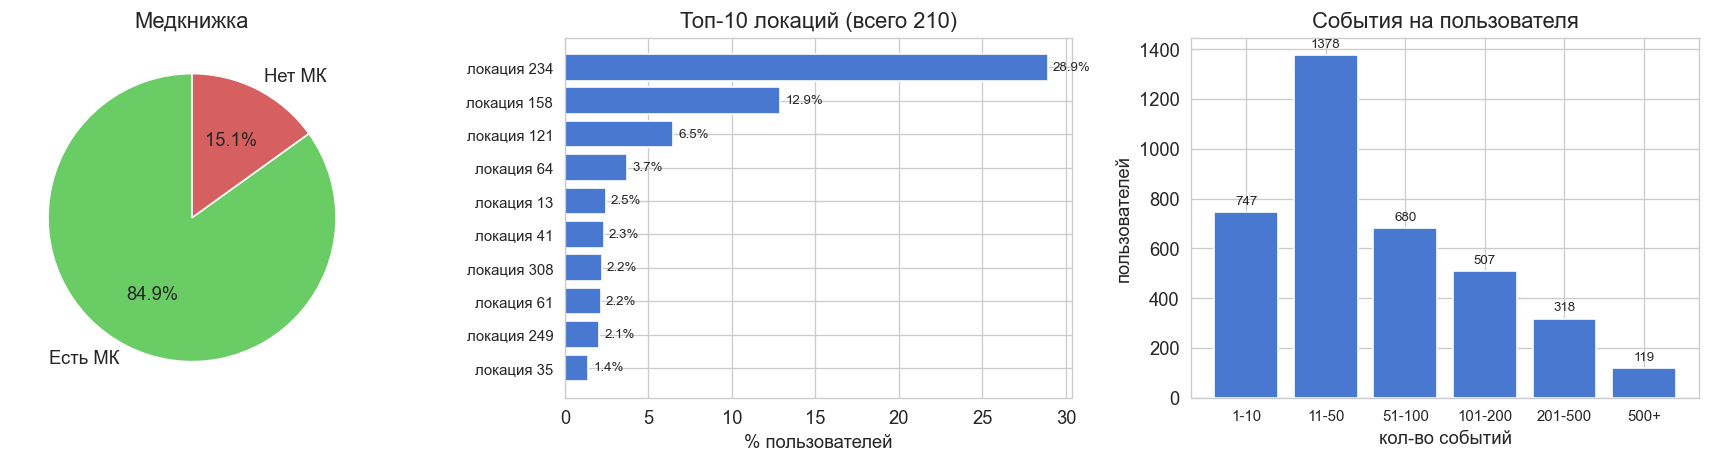

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Медкнижка
mk_counts = users['has_mk'].value_counts()
labels = ['Есть МК' if k else 'Нет МК' for k in mk_counts.index]
colors_mk = ['#6ACC65' if k else '#D65F5F' for k in mk_counts.index]
axes[0].pie(mk_counts.values, labels=labels,
            colors=colors_mk, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Медкнижка')

# Топ локаций:  % пользователей в каждой из топ-10
top_locs = users['location_id'].value_counts().head(10)
top_locs_pct = top_locs / len(users) * 100
axes[1].barh(range(len(top_locs_pct)), top_locs_pct.values, color='#4878CF')
axes[1].set_yticks(range(len(top_locs_pct)))
axes[1].set_yticklabels([f'локация {x}' for x in top_locs_pct.index], fontsize=9)
for i, v in enumerate(top_locs_pct.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
axes[1].set_title(f'Топ-10 локаций (всего {users["location_id"].nunique()})')
axes[1].set_xlabel('% пользователей')
axes[1].invert_yaxis()

# Активность
user_activity = events.groupby('user_id').size()
bins = [0, 10, 50, 100, 200, 500, user_activity.max() + 1]
labels_act = ['1-10', '11-50', '51-100', '101-200', '201-500', '500+']
act_binned = pd.cut(user_activity, bins=bins, labels=labels_act, right=True)
counts = act_binned.value_counts().reindex(labels_act)
axes[2].bar(range(len(counts)), counts.values, color='#4878CF')
axes[2].set_xticks(range(len(counts)))
axes[2].set_xticklabels(counts.index, fontsize=9)
for i, v in enumerate(counts.values):
    axes[2].text(i, v + 30, f'{v}', ha='center', fontsize=8)
axes[2].set_title('События на пользователя')
axes[2].set_xlabel('кол-во событий')
axes[2].set_ylabel('пользователей')

plt.tight_layout()
plt.show()


In [11]:
pd.DataFrame({
    'users':  [len(users), users['has_mk'].sum(), users['location_id'].nunique(), user_activity.median()],
}, index=['всего', 'с МК', 'локаций', 'медиана событий'])

,users
всего,5154.0
с МК,4377.0
локаций,210.0
медиана событий,39.0


- 84.9% пользователей с медкнижкой
- Локации сильно концентрированы: одна локация 234 = 29% всех пользователей, топ-2 локации = 42%. Всего 210 уникальных локаций  
- Активность: большинство пользователей делает 11-50 событий (27%), дальше монотонный спад - гиперактивных мало (500+ событий только у 2%)


## EDA: смены

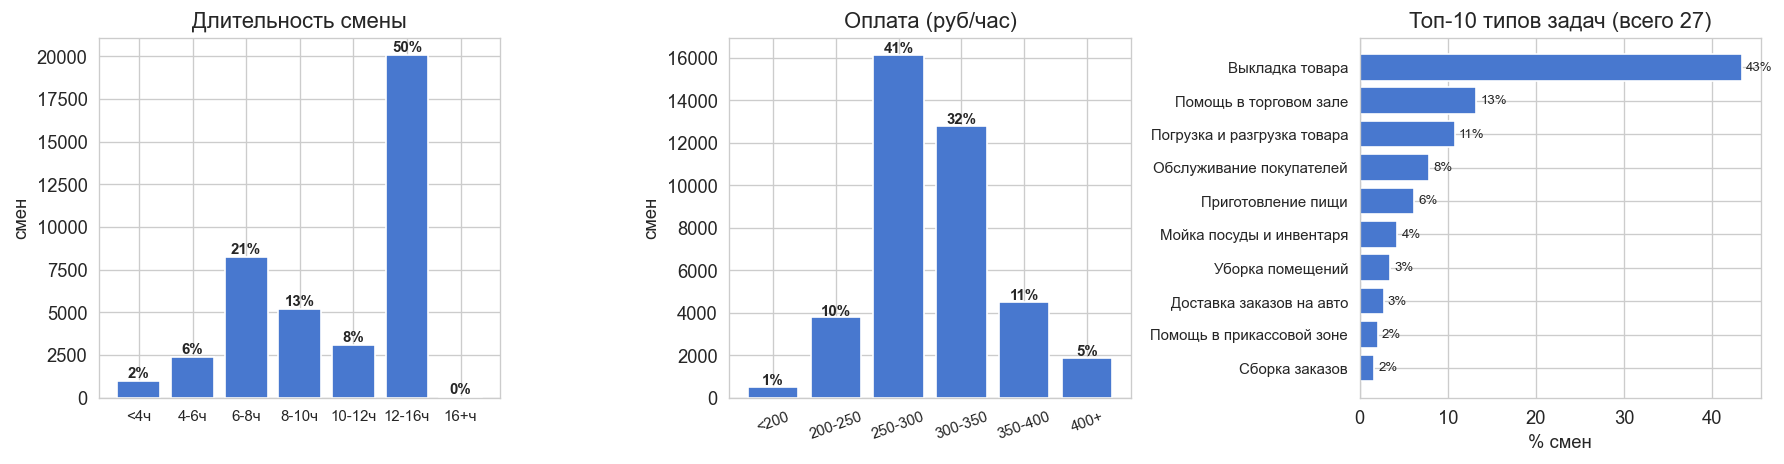

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Длительность
hours_bins = [0, 4, 6, 8, 10, 12, 16, 24]
hours_labels = ['<4ч', '4-6ч', '6-8ч', '8-10ч', '10-12ч', '12-16ч', '16+ч']
hours_binned = pd.cut(shifts['hours'].dropna(), bins=hours_bins, labels=hours_labels, right=False)
counts = hours_binned.value_counts().reindex(hours_labels)
pct = counts / counts.sum() * 100
bars = axes[0].bar(range(len(counts)), counts.values, color='#4878CF')
for bar, v, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, fontsize=9)
axes[0].set_title('Длительность смены')
axes[0].set_ylabel('смен')

# Оплата в час
shifts['reward_per_hour'] = shifts['reward'] / shifts['hours'].clip(lower=1)
rph_bins = [0, 200, 250, 300, 350, 400, 600]
rph_labels = ['<200', '200-250', '250-300', '300-350', '350-400', '400+']
rph_binned = pd.cut(shifts['reward_per_hour'].dropna(), bins=rph_bins, labels=rph_labels, right=False)
counts = rph_binned.value_counts().reindex(rph_labels)
pct = counts / counts.sum() * 100
bars = axes[1].bar(range(len(counts)), counts.values, color='#4878CF')
for bar, v, p in zip(bars, counts.values, pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{p:.0f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, fontsize=9, rotation=20)
axes[1].set_title('Оплата (руб/час)')
axes[1].set_ylabel('смен')

# Типы задач
task_counts = shifts['task_type'].value_counts().head(10)
task_pct = task_counts / len(shifts) * 100
axes[2].barh(range(len(task_pct)), task_pct.values, color='#4878CF')
axes[2].set_yticks(range(len(task_pct)))
axes[2].set_yticklabels(task_pct.index, fontsize=9)
for i, v in enumerate(task_pct.values):
    axes[2].text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=8)
axes[2].set_title(f'Топ-10 типов задач (всего {shifts["task_type"].nunique()})')
axes[2].set_xlabel('% смен')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()


In [13]:
shifts[['hours','reward','capacity']].describe().loc[['mean','50%','max']].round(1)

,hours,reward,capacity
mean,9.9,2991.4,1.2
50%,12.0,3100.0,1.0
max,22.0,9500.0,154.0


- Длительность: половина смен по 12-16 часов, остальное в основном 6-10 часов
- Оплата: 73% смен в диапазоне 250-350 руб/час
- Типы задач: топ-3 (Выкладка, Помощь в зале, Погрузка) забирают 67% из 27 типов


## EDA: события

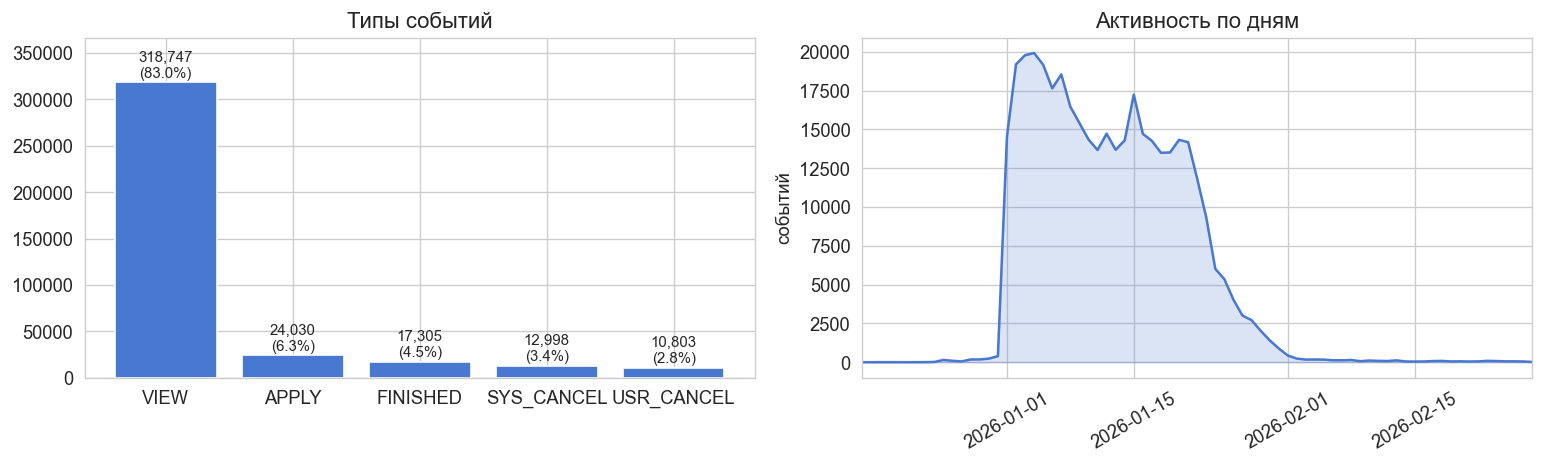

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Типы событий
ev_counts = events['interaction'].value_counts()
total_ev = ev_counts.sum()
ev_labels_short = {'VIEW':'VIEW', 'APPLY':'APPLY', 'FINISHED':'FINISHED',
                    'SYSTEM_CANCEL':'SYS_CANCEL', 'USER_CANCEL':'USR_CANCEL'}
labels = [ev_labels_short[i] for i in ev_counts.index]
bars = axes[0].bar(labels, ev_counts.values, color='#4878CF')
for bar, v in zip(bars, ev_counts.values):
    pct = v / total_ev * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('Типы событий')
axes[0].set_ylim(0, ev_counts.max() * 1.15)

# Активность по дням 
events['date'] = events['ts'].dt.date
daily = events.groupby('date').size().reset_index(name='cnt')
daily['date'] = pd.to_datetime(daily['date'])
daily = daily[daily['cnt'] > 0]  
axes[1].plot(daily['date'], daily['cnt'], linewidth=1.5, color='#4878CF')
axes[1].fill_between(daily['date'], daily['cnt'], alpha=0.2, color='#4878CF')
axes[1].set_title('Активность по дням')
axes[1].set_ylabel('событий')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_xlim(daily['date'].min(), daily['date'].max())

plt.tight_layout()
plt.show()


In [15]:
n_v = (events['interaction']=='VIEW').sum()
n_a = (events['interaction']=='APPLY').sum()
n_f = (events['interaction']=='FINISHED').sum()
print(f'VIEW:          {n_v:>7,}')
print(f'APPLY:         {n_a:>7,}   ({n_a/n_v*100:.1f}% от VIEW)')
print(f'FINISHED:      {n_f:>7,}   ({n_f/n_a*100:.1f}% от APPLY)')

VIEW:          318,747
APPLY:          24,030   (7.5% от VIEW)
FINISHED:       17,305   (72.0% от APPLY)


- VIEW доминирует (83% всех событий), APPLY 6.3%, FINISHED 4.5%
- Только 7.5% просмотров превращаются в APPLY (24,030 из 318,747)
- 72% из APPLY доходят до FINISHED - кто решился, тот обычно выходит
- Отмены (12,998 SYS + 10,803 USR) почти равны числу APPLY - люди часто передумывают после подачи
- Активность: данные за январь–февраль 2026, резкий рост с 1 января и спад к концу января (всплеск на новогодних каникулах)


## Дисбаланс классов

APPLY/FINISHED могут прийти после start_at (записались в день смены). Поэтому таргет берём из всех событий, а признаки только до start_at.

In [16]:
shifts_info = shifts.rename(columns={'id':'shift_id'})[
    ['shift_id','start_at','employer_id','workplace_id','task_type','hours']
]
ev = events.merge(shifts_info, on='shift_id', how='inner')
ev_before = ev[ev['ts'] < ev['start_at']].copy()

apply_fin = ev[ev['interaction'].isin(['APPLY','FINISHED'])]
after = apply_fin[apply_fin['ts'] >= apply_fin['start_at']]
print(f'после start_at: {len(after)} ({len(after)/len(apply_fin)*100:.1f}%)')

после start_at: 646 (1.6%)


1.6% событий после start_at, поэтому таргет берём из всех событий, а признаки только до start_at

In [17]:
pairs_base = ev_before.groupby(['user_id','shift_id'], as_index=False).agg(
    view_cnt=('interaction', lambda s: (s=='VIEW').sum()),
    apply_cnt=('interaction', lambda s: (s=='APPLY').sum()),
    finished_cnt=('interaction', lambda s: (s=='FINISHED').sum()),
    user_cancel_cnt=('interaction', lambda s: (s=='USER_CANCEL').sum()),
)

target_all = ev[ev['interaction'].isin(['APPLY','FINISHED'])][['user_id','shift_id']].drop_duplicates()
target_all['target'] = 1
pairs_base = pairs_base.merge(target_all, on=['user_id','shift_id'], how='left')
pairs_base['target'] = pairs_base['target'].fillna(0).astype(int)

n_pos = pairs_base['target'].sum()
n_neg = len(pairs_base) - n_pos
print(f'{len(pairs_base):,}  |  1:{n_neg//n_pos}  |  pos {n_pos/len(pairs_base)*100:.1f}%')

274,743  |  1:7  |  pos 11.6%


In [18]:
print(f'всего пар: {len(pairs_base):,}')
print(f'позитивных (target=1): {n_pos:,} ({n_pos/len(pairs_base)*100:.1f}%)')
print(f'негативных (target=0): {n_neg:,} ({n_neg/len(pairs_base)*100:.1f}%)')
print(f'соотношение 1:{n_neg//n_pos}')

всего пар: 274,743
позитивных (target=1): 31,737 (11.6%)
негативных (target=0): 243,006 (88.4%)
соотношение 1:7


Из 274 743 пар только 11.6% (~31 737) - это случаи когда пользователь подал заявку или вышел на смену. Остальные 88.4% - негативы (посмотрел и не подал).

Соотношение 1:7 → используем scale_pos_weight=7 в бустингах чтобы модель не игнорировала редкий класс.

## Анализ конверсий

Смотрим как разные признаки влияют на конверсию (target=1). Большой разрыв между группами = сильный признак для модели.


In [19]:
pairs_base = pairs_base.merge(shifts_info[['shift_id','start_at']], on='shift_id', how='left')
shifts_extra = shifts.rename(columns={'id':'shift_id'}).drop(columns=['start_at'], errors='ignore')
pairs_base = pairs_base.merge(shifts_extra, on='shift_id', how='inner')
pairs_base = pairs_base.merge(
    users.rename(columns={'id':'user_id','location_id':'user_location_id'})[['user_id','user_location_id','has_mk','is_strict_location']],
    on='user_id', how='left'
)

BASE_RATE = pairs_base['target'].mean()
print(f'BASE_RATE: {BASE_RATE:.1%}')

BASE_RATE: 11.6%


In [20]:
fin_before = ev_before[ev_before['interaction']=='FINISHED']

fin_wp = fin_before[['user_id','workplace_id','start_at']].rename(columns={'start_at':'fin_at'})
wp_check = pairs_base[['user_id','shift_id','workplace_id','start_at']].merge(fin_wp, on=['user_id','workplace_id'], how='left')
wp_check = wp_check[wp_check['fin_at'] < wp_check['start_at']][['user_id','shift_id']].drop_duplicates()
wp_check['worked_workplace_before'] = 1
pairs_base = pairs_base.merge(wp_check, on=['user_id','shift_id'], how='left')
pairs_base['worked_workplace_before'] = pairs_base['worked_workplace_before'].fillna(0).astype(int)

fin_emp = fin_before[['user_id','employer_id','start_at']].rename(columns={'start_at':'fin_at'})
emp_check = pairs_base[['user_id','shift_id','employer_id','start_at']].merge(fin_emp, on=['user_id','employer_id'], how='left')
emp_check = emp_check[emp_check['fin_at'] < emp_check['start_at']][['user_id','shift_id']].drop_duplicates()
emp_check['worked_employer_before'] = 1
pairs_base = pairs_base.merge(emp_check, on=['user_id','shift_id'], how='left')
pairs_base['worked_employer_before'] = pairs_base['worked_employer_before'].fillna(0).astype(int)

pairs_base['same_location'] = (pairs_base['location_id'].astype(str) == pairs_base['user_location_id'].astype(str)).astype(int)
pairs_base['mk_ok']         = (pairs_base['has_mk'].astype(float) >= pairs_base['need_mk'].astype(float)).astype(int)
pairs_base['id_diff_int']   = pairs_base['id_differential'].astype(int)

shares = pairs_base[['worked_workplace_before','worked_employer_before','same_location','mk_ok']].mean()
print('Доля пар с признаком = 1:')
for col, val in shares.items():
    print(f'  {col:<25} {val*100:5.1f}%')

Доля пар с признаком = 1:
  worked_workplace_before    15.4%
  worked_employer_before     55.8%
  same_location              71.4%
  mk_ok                      99.0%


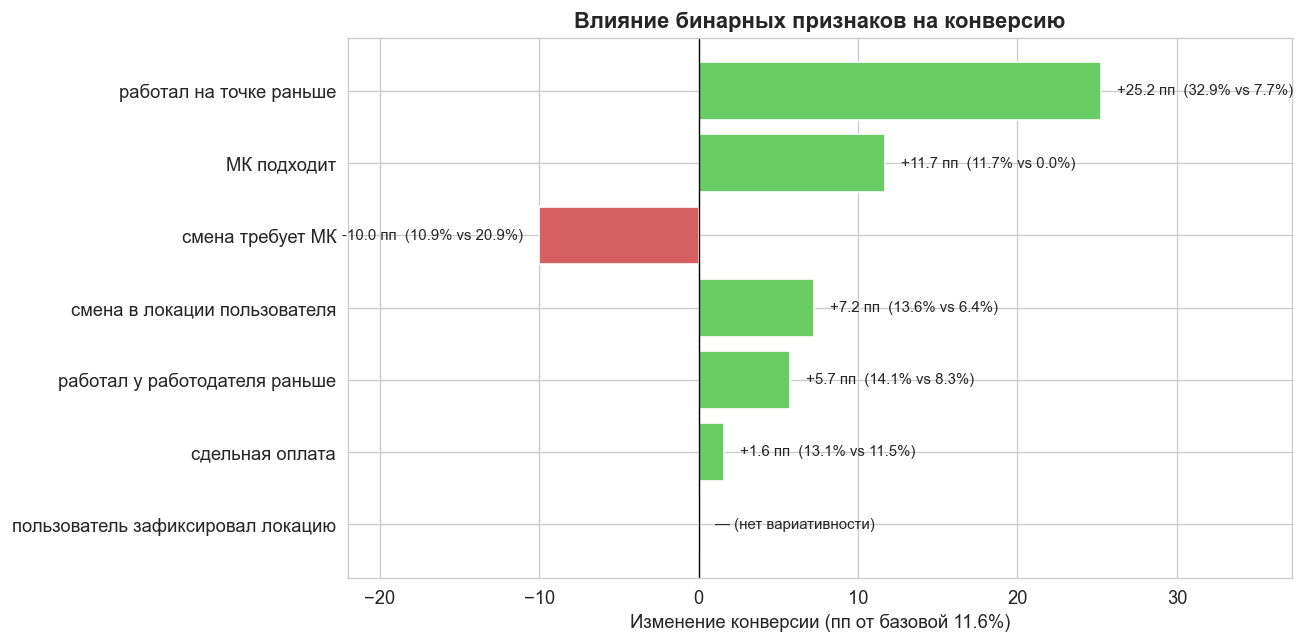

,признак,=0 (%),=1 (%),разница (пп),доля =1 (%)
0,пользователь зафиксировал локацию,11.6,NaN,NaN,0.0
1,сдельная оплата,11.5,13.1,1.6,3.7
2,работал у работодателя раньше,8.3,14.1,5.7,55.8
3,смена в локации пользователя,6.4,13.6,7.2,71.4
4,смена требует МК,20.9,10.9,-10.0,93.5
5,МК подходит,0.0,11.7,11.7,99.0
6,работал на точке раньше,7.7,32.9,25.2,15.4


In [21]:
# создаём служебные int-колонки если их ещё нет
if 'need_mk_int' not in pairs_base.columns:
    pairs_base['need_mk_int'] = pairs_base['need_mk'].astype(int)
if 'id_diff_int' not in pairs_base.columns:
    pairs_base['id_diff_int'] = pairs_base['id_differential'].astype(int)
pairs_base['is_strict_int'] = pairs_base['is_strict_location'].astype(int)

features_binary = [
    ('worked_workplace_before',  'работал на точке раньше'),
    ('worked_employer_before',   'работал у работодателя раньше'),
    ('mk_ok',                    'МК подходит'),
    ('need_mk_int',              'смена требует МК'),
    ('id_diff_int',              'сдельная оплата'),
    ('same_location',            'смена в локации пользователя'),
    ('is_strict_int',            'пользователь зафиксировал локацию')
]

rows = []
for col, label_ru in features_binary:
    cv0 = pairs_base.loc[pairs_base[col] == 0, 'target'].mean() * 100
    cv1 = pairs_base.loc[pairs_base[col] == 1, 'target'].mean() * 100
    share = pairs_base[col].mean() * 100
    rows.append({
        'признак': label_ru,
        '=0 (%)': cv0,
        '=1 (%)': cv1,
        'разница (пп)': cv1 - cv0,
        'доля =1 (%)': share,
    })

df_binary = pd.DataFrame(rows).sort_values('разница (пп)', key=abs, ascending=True, na_position='first')

fig, ax = plt.subplots(figsize=(11, 5.5))
colors = ['#6ACC65' if d > 0 else '#D65F5F' if d < 0 else '#BBBBBB'
          for d in df_binary['разница (пп)'].fillna(0)]
bars = ax.barh(df_binary['признак'], df_binary['разница (пп)'].fillna(0), color=colors)

for bar, row in zip(bars, df_binary.itertuples()):
    diff = row._4 if pd.notna(row._4) else 0
    sign = '+' if diff > 0 else ''
    if pd.isna(row._4):
        label = '— (нет вариативности)'
    else:
        label = f'{sign}{diff:.1f} пп  ({row._3:.1f}% vs {row._2:.1f}%)'
    offset = 1.0 if diff >= 0 else -1.0
    ha = 'left' if diff >= 0 else 'right'
    ax.text(diff + offset, bar.get_y() + bar.get_height()/2,
            label, va='center', ha=ha, fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Изменение конверсии (пп от базовой 11.6%)')
ax.set_title('Влияние бинарных признаков на конверсию', fontweight='bold')

xmax = df_binary['разница (пп)'].max()
xmin = df_binary['разница (пп)'].min()
ax.set_xlim(xmin - 12, xmax + 12)

plt.tight_layout()
plt.show()

df_binary.round(1).reset_index(drop=True)


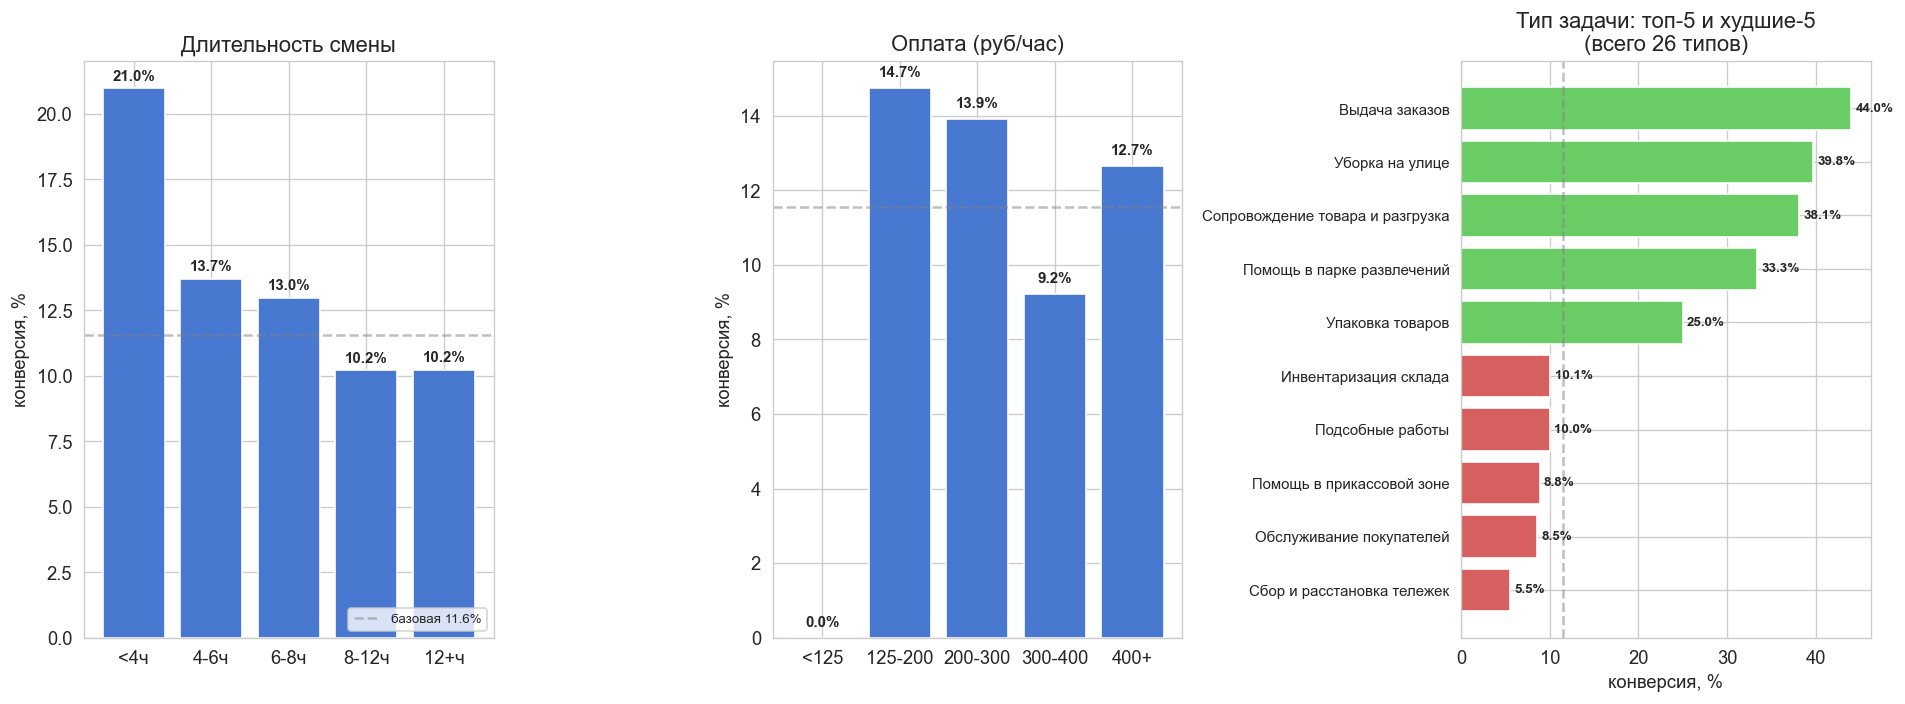

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Длительность смены 
pairs_base['hours_bin'] = pd.cut(pairs_base['hours'], bins=[0,4,6,8,12,99],
                                  labels=['<4ч','4-6ч','6-8ч','8-12ч','12+ч'])
cv = pairs_base.groupby('hours_bin', observed=True)['target'].mean() * 100
bars = axes[0].bar(cv.index, cv.values, color='#4878CF')
for bar, v in zip(bars, cv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5, label='базовая 11.6%')
axes[0].set_title('Длительность смены')
axes[0].set_ylabel('конверсия, %')
axes[0].legend(loc='lower right', fontsize=8)

# Оплата
pairs_base['rph'] = pairs_base['reward'] / pairs_base['hours'].clip(lower=1)
pairs_base['rph_bin'] = pd.cut(pairs_base['rph'].clip(upper=500),
                                bins=[0,125,200,300,400,500],
                                labels=['<125','125-200','200-300','300-400','400+'])
cv = pairs_base.groupby('rph_bin', observed=True)['target'].mean() * 100
bars = axes[1].bar(cv.index, cv.values, color='#4878CF')
for bar, v in zip(bars, cv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Оплата (руб/час)')
axes[1].set_ylabel('конверсия, %')

# Топ-10 типов задач 
cv_tasks = pairs_base.groupby('task_type')['target'].mean().sort_values() * 100
top_bottom = pd.concat([cv_tasks.head(5), cv_tasks.tail(5)])
colors_tasks = ['#D65F5F'] * 5 + ['#6ACC65'] * 5
bars = axes[2].barh(range(len(top_bottom)), top_bottom.values, color=colors_tasks)
axes[2].set_yticks(range(len(top_bottom)))
axes[2].set_yticklabels(top_bottom.index, fontsize=9)
for i, v in enumerate(top_bottom.values):
    axes[2].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8, fontweight='bold')
axes[2].axvline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title(f'Тип задачи: топ-5 и худшие-5\n(всего {pairs_base["task_type"].nunique()} типов)')
axes[2].set_xlabel('конверсия, %')

plt.tight_layout()
plt.show()


**Топ сигналы:**
- Тип задачи даёт огромный разброс конверсии: от 5.5% (Сбор тележек) до 44% (Выдача заказов) - в 8 раз
- Длительность: короткие смены <4ч (21%) берут в 2 раза охотнее длинных (10%)
- Оплата: немонотонная зависимость - 250-300 руб/ч лучше чем 300-400. Высокая цена не помогает

**Гипотезы:**
- Короткие смены = низкий порог входа, легче решиться
- Дорогие смены могут быть сложнее (квалификация, физическая нагрузка), поэтому конверсия ниже несмотря на оплату
- Лидер "Выдача заказов" - массовая простая работа, отсюда популярность


## Сезонность

In [23]:
NEW_YEAR_HOLIDAYS = {(1, d) for d in range(1, 9)}

pairs_base['weekday']     = pairs_base['start_at'].dt.dayofweek
pairs_base['hour_shift']  = pairs_base['start_at'].dt.hour
pairs_base['day_of_month']= pairs_base['start_at'].dt.day
pairs_base['month_shift'] = pairs_base['start_at'].dt.month
pairs_base['is_holiday']  = pairs_base['start_at'].apply(
    lambda x: int((x.month, x.day) in NEW_YEAR_HOLIDAYS) if pd.notnull(x) else 0
)
pairs_base[['weekday','hour_shift','is_holiday']].head(3)

,weekday,hour_shift,is_holiday
0,3,10,0
1,1,10,0
2,4,11,0


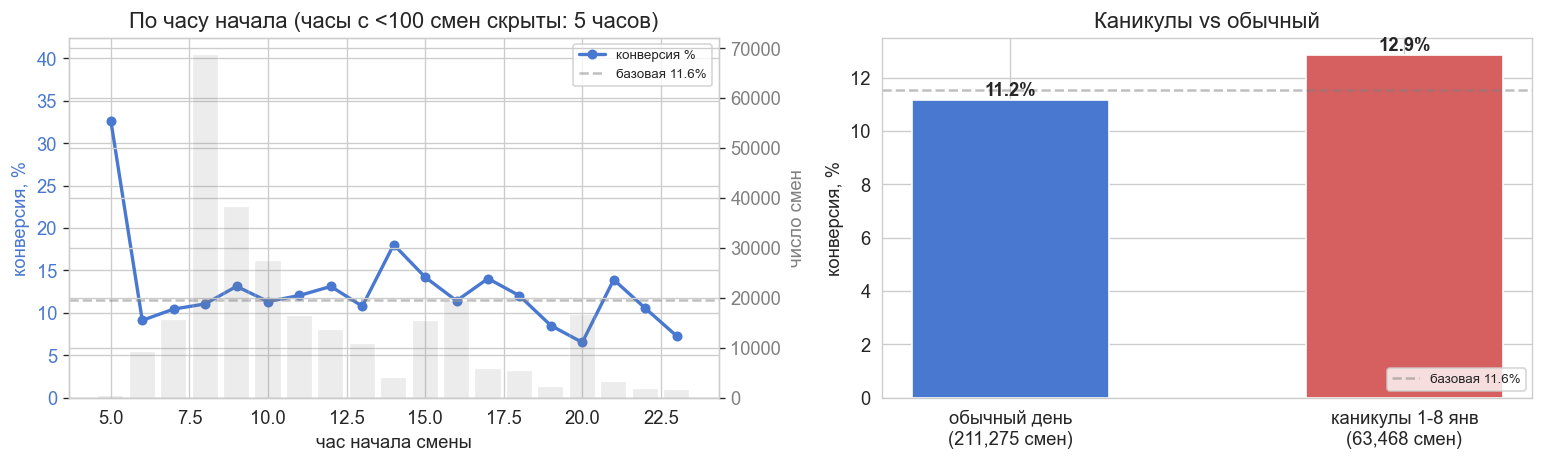

По дням недели разброс: 11.0% – 11.9% (разница 0.9 пп — слабый признак)


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Час начала: фильтруем редкие часы (<100 смен), показываем двойной график
hour_stats = pairs_base.groupby('hour_shift').agg(
    cv=('target', lambda s: s.mean() * 100),
    n=('target', 'size'),
).reset_index()
hour_stats_main = hour_stats[hour_stats['n'] >= 100]  # только значимые

ax1 = axes[0]
ax2 = ax1.twinx()

# Линия конверсии
ax1.plot(hour_stats_main['hour_shift'], hour_stats_main['cv'],
         linewidth=2, marker='o', markersize=5, color='#4878CF', label='конверсия %')
ax1.axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5, label='базовая 11.6%')
ax1.set_xlabel('час начала смены')
ax1.set_ylabel('конверсия, %', color='#4878CF')
ax1.tick_params(axis='y', labelcolor='#4878CF')
ax1.set_ylim(0, max(hour_stats_main['cv']) * 1.3)

# Объём как фон
ax2.bar(hour_stats_main['hour_shift'], hour_stats_main['n'],
        alpha=0.15, color='gray', width=0.8)
ax2.set_ylabel('число смен', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

ax1.set_title(f'По часу начала (часы с <100 смен скрыты: {(hour_stats["n"] < 100).sum()} часов)')
ax1.legend(loc='upper right', fontsize=8)

# Каникулы vs обычный — с контекстом по объёму
cv = pairs_base.groupby('is_holiday').agg(
    cv=('target', lambda s: s.mean() * 100),
    n=('target', 'size'),
)
labels = [f'обычный день\n({cv.loc[0,"n"]:,} смен)', f'каникулы 1-8 янв\n({cv.loc[1,"n"]:,} смен)']
colors_hol = ['#4878CF', '#D65F5F']
bars = axes[1].bar(labels, [cv.loc[0,'cv'], cv.loc[1,'cv']],
                    color=colors_hol, width=0.5)
for bar, v in zip(bars, [cv.loc[0,'cv'], cv.loc[1,'cv']]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5, label='базовая 11.6%')
axes[1].set_title('Каникулы vs обычный')
axes[1].set_ylabel('конверсия, %')
axes[1].legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

# День недели — одной строчкой текстом, графика недостаточно сигнала
weekday_cv = pairs_base.groupby('weekday')['target'].mean() * 100
print(f'По дням недели разброс: {weekday_cv.min():.1f}% – {weekday_cv.max():.1f}% (разница {weekday_cv.max()-weekday_cv.min():.1f} пп — слабый признак)')


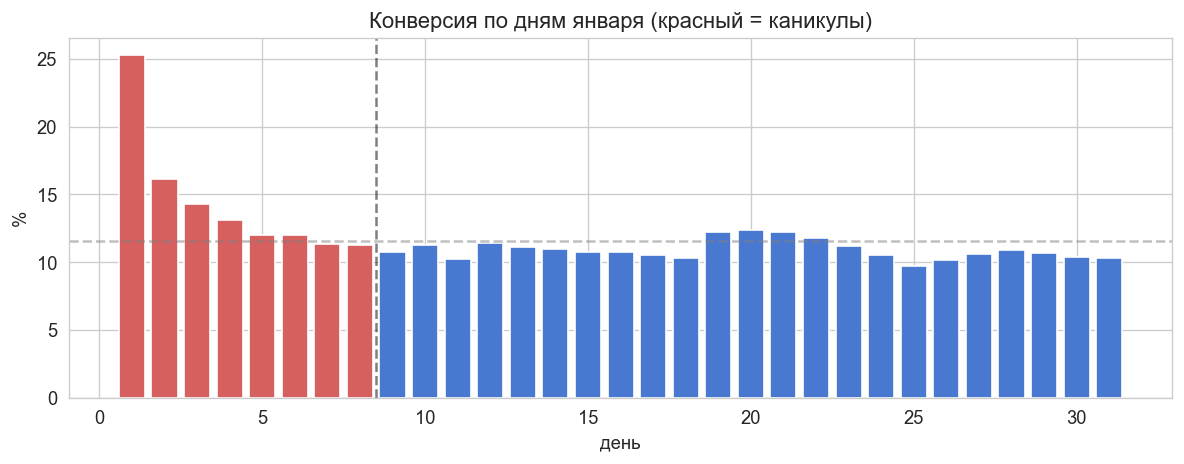

In [25]:
# конверсия по дням января
jan = pairs_base[pairs_base['month_shift']==1]
cv_jan = jan.groupby('day_of_month')['target'].mean() * 100
colors_jan = ['#D65F5F' if d <= 8 else '#4878CF' for d in cv_jan.index]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cv_jan.index, cv_jan.values, color=colors_jan, edgecolor='white')
ax.axvline(8.5, color='black', linestyle='--', alpha=0.5)
ax.axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Конверсия по дням января (красный = каникулы)')
ax.set_xlabel('день')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

День недели: почти нет разницы, признак слабый.

Час начала: аномальный пик в 2–5 ночи (~75% и ~35%), скорее всего единичные смены с особой аудиторией. В остальное время стабильно ~11–14%.

Каникулы: агрегированно разница небольшая (12.9% и 11.2%), но по дням января видно, что 1 января пик 25%, затем плавное падение к 8-му до базового уровня. Какой-то эффект первого января прямо таки :)

## История пользователя и активность

In [26]:
last_active = ev_before.groupby(['user_id','shift_id'])['ts'].max().reset_index(name='last_ts')
pairs_base = pairs_base.merge(last_active, on=['user_id','shift_id'], how='left')
pairs_base['recency_days'] = (
    (pairs_base['start_at'] - pairs_base['last_ts']).dt.total_seconds() / 86400
).clip(lower=0)
pairs_base['recency_days'].describe().round(1)

count    274743.0
mean          3.9
std           4.3
min           0.0
25%           1.3
50%           2.4
75%           4.7
max          59.3
Name: recency_days, dtype: float64

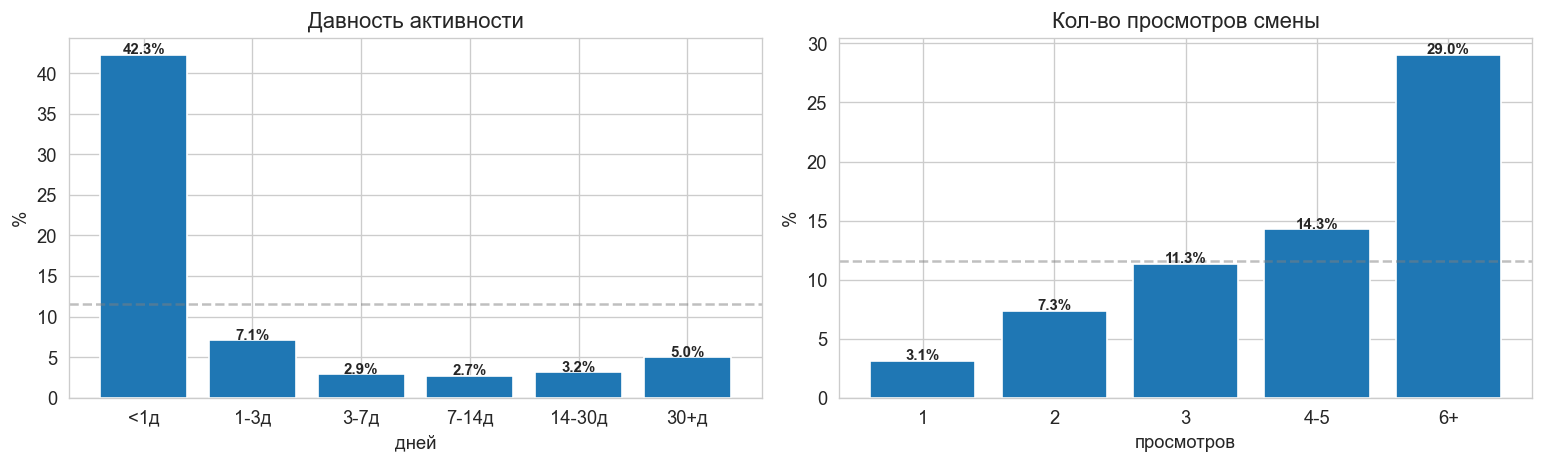

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pairs_base['recency_bin'] = pd.cut(pairs_base['recency_days'],
    bins=[0,1,3,7,14,30,999], labels=['<1д','1-3д','3-7д','7-14д','14-30д','30+д'])
cv = pairs_base.groupby('recency_bin', observed=True)['target'].mean() * 100
bars = axes[0].bar(cv.index, cv.values)
for bar, v in zip(bars, cv.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Давность активности')
axes[0].set_ylabel('%')
axes[0].set_xlabel('дней')

pairs_base['view_bin'] = pd.cut(pairs_base['view_cnt'],
    bins=[0,1,2,3,5,99], labels=['1','2','3','4-5','6+'])
cv = pairs_base.groupby('view_bin', observed=True)['target'].mean() * 100
bars = axes[1].bar(cv.index, cv.values)
for bar, v in zip(bars, cv.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Кол-во просмотров смены')
axes[1].set_ylabel('%')
axes[1].set_xlabel('просмотров')

plt.tight_layout()
plt.show()

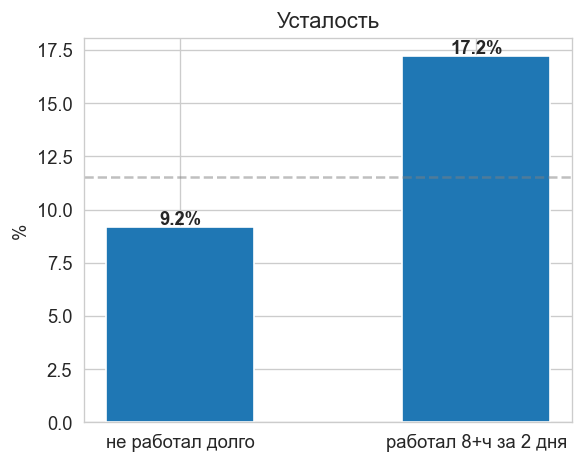

worked_long_recently
0    194011
1     80732
Name: count, dtype: int64

In [28]:
# усталость
shift_hrs = shifts.rename(columns={'id':'shift_id'})[['shift_id','hours']].rename(columns={'hours':'sh'})
fin_long = ev_before[ev_before['interaction']=='FINISHED'].merge(shift_hrs, on='shift_id', how='left')

fatigue = pairs_base[['user_id','shift_id','start_at']].merge(
    fin_long[['user_id','shift_id','ts','sh']].rename(columns={'shift_id':'fin_shift','ts':'fin_ts'}),
    on='user_id', how='left'
)
fatigue = fatigue[
    (fatigue['fin_ts'] < fatigue['start_at']) &
    ((fatigue['start_at'] - fatigue['fin_ts']).dt.total_seconds() < 2*86400) &
    (fatigue['sh'] >= 8)
][['user_id','shift_id']].drop_duplicates()
fatigue['worked_long_recently'] = 1
pairs_base = pairs_base.merge(fatigue, on=['user_id','shift_id'], how='left')
pairs_base['worked_long_recently'] = pairs_base['worked_long_recently'].fillna(0).astype(int)

cv = pairs_base.groupby('worked_long_recently')['target'].mean() * 100
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['не работал долго','работал 8+ч за 2 дня'],
               [cv.get(0,0), cv.get(1,0)], width=0.5)
for bar, v in zip(bars, [cv.get(0,0), cv.get(1,0)]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}%', ha='center', fontweight='bold')
ax.axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Усталость')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()
pairs_base["worked_long_recently"].value_counts()


Чем свежее давность активности, тем лучше. Если смотрел смену менее суток назад - 42.3%, потом резкое падение до 3-7%. Медиана 2.4 дня, т.е. большинство решают быстро.

Просмотры смены: монотонный рост, кто смотрел 6+ раз конвертирует в 29%. Повторные просмотры = реальный интерес.

Усталость выдала неожиданное: работал 8+ч за 2 дня - конверсия выше (17.2% и 9.2%). Это активные пользователи, а не уставшие, они в рабочем режиме и берут следующую смену.

## Парадоксы

Несколько наблюдений, которые тоже влияют на результат модели

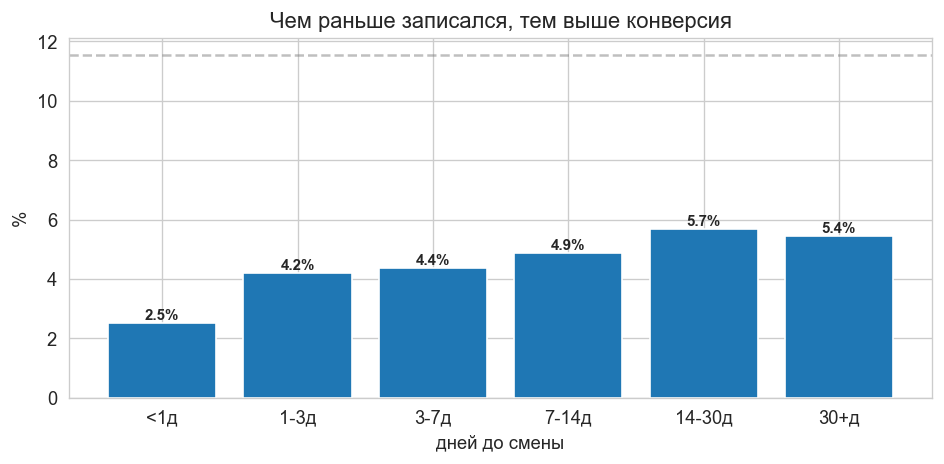

In [29]:
# ожидали: срочные смены берут охотнее, а оказалось наоборот
first_view = ev_before[ev_before['interaction']=='VIEW'].groupby(['user_id','shift_id'])['ts'].min().reset_index(name='first_view_ts')
pb2 = pairs_base.merge(first_view, on=['user_id','shift_id'], how='left')
pb2['days_to_shift'] = ((pb2['start_at'] - pb2['first_view_ts']).dt.total_seconds() / 86400).clip(lower=0)
pb2['dts_bin'] = pd.cut(pb2['days_to_shift'].fillna(0),
    bins=[0,1,3,7,14,30,999], labels=['<1д','1-3д','3-7д','7-14д','14-30д','30+д'])
cv = pb2.groupby('dts_bin', observed=True)['target'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cv.index, cv.values)
for bar, v in zip(bars, cv.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(BASE_RATE*100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Чем раньше записался, тем выше конверсия')
ax.set_xlabel('дней до смены')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

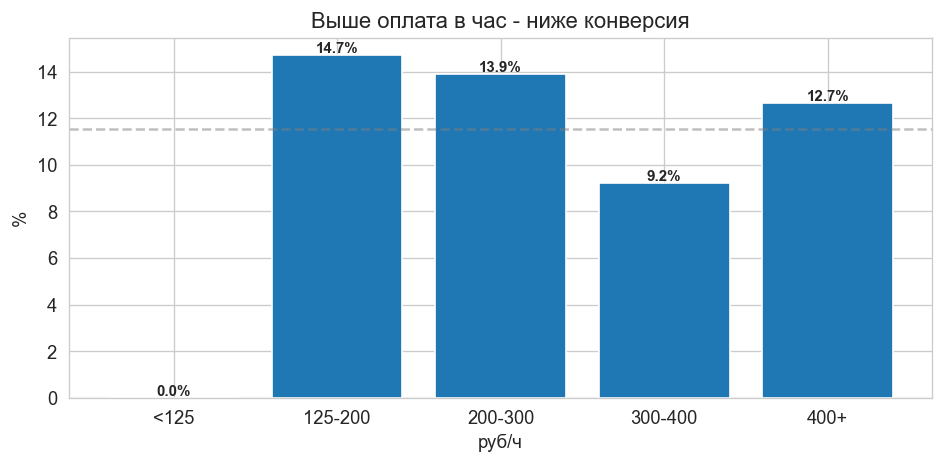

In [30]:
# выше оплата → ниже конверсия
pairs_base['rph_bin2'] = pd.cut(
    pairs_base['rph'].clip(upper=500),
    bins=[0, 125, 200, 300, 400, 500],
    labels=['<125', '125-200', '200-300', '300-400', '400+']
)
cv_rph = pairs_base.groupby('rph_bin2', observed=True)['target'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cv_rph.index, cv_rph.values)
for bar, v in zip(bars, cv_rph.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.axhline(BASE_RATE * 100, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Выше оплата в час - ниже конверсия')
ax.set_xlabel('руб/ч')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

In [31]:
# посмотрим на признак is_strict_location
strict_share = pairs_base['is_strict_location'].astype(int).mean() * 100
print(f'is_strict_location = True: {strict_share:.1f}% пар')
print(f'is_strict_location = False: {100 - strict_share:.1f}% пар')
print()
print(users['is_strict_location'].value_counts())


is_strict_location = True: 0.0% пар
is_strict_location = False: 100.0% пар

is_strict_location
False    5154
Name: count, dtype: int64


В текущих данных у **всех 5154 пользователей** `is_strict_location = False`. Признак константа и в EDA сигнала не несёт.

Почему всё равно оставляем в `FEATURES`:
- заказчик явно перечисляет его как пользовательский признак в спецификации
- в проде распределение может измениться (появятся пользователи с `True`)
- модель готова это учесть когда сигнал появится

На обучении сейчас он не влияет, но обеспечит корректное поведение в проде.


## Сплит данных

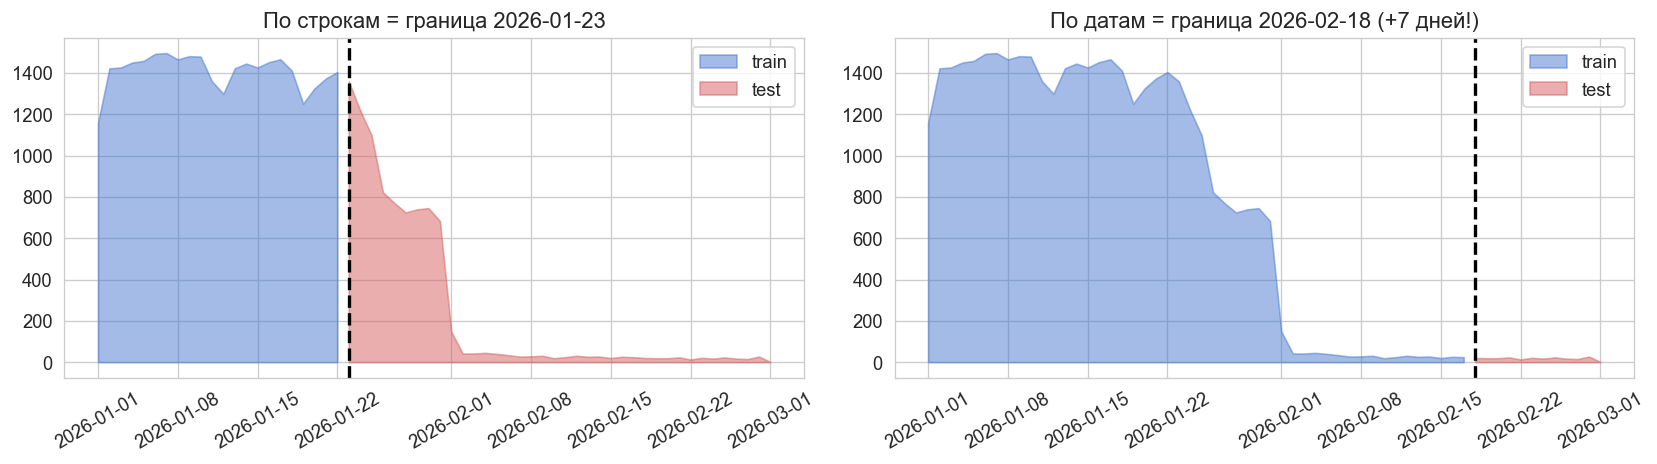

In [32]:
shifts['date'] = shifts['start_at'].dt.date
daily_s = shifts.groupby('date').size().reset_index(name='cnt')
daily_s['date'] = pd.to_datetime(daily_s['date'])
daily_s = daily_s.sort_values('date').reset_index(drop=True)

unique_dates = sorted(daily_s['date'].unique())
border_date = unique_dates[int(len(unique_dates)*0.8)]

all_flat = shifts.sort_values('start_at')['start_at'].dt.date
row_border = pd.to_datetime(all_flat.iloc[int(len(all_flat)*0.8)])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, title, border in [
    (axes[0], f'По строкам = граница {row_border.date()}', row_border),
    (axes[1], f'По датам = граница {border_date.date()} (+7 дней!)', border_date),
]:
    mask = daily_s['date'] < border
    ax.fill_between(daily_s['date'], daily_s['cnt'], where=mask,  alpha=0.5, color='#4878CF', label='train')
    ax.fill_between(daily_s['date'], daily_s['cnt'], where=~mask, alpha=0.5, color='#D65F5F', label='test')
    ax.axvline(border, color='black', linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.legend()
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Сплит по строкам: граница 23 января, test попадает в самый хвост данных где смен уже мало, модель не видит конец периода.

Сплит по датам: граница 18 февраля, train покрывает весь активный период включая пик января, а test конец февраля. +7 дней обучения.

Оба варианта дают маленький test, так как данные сами по себе короткие (январь–февраль). Это нормально для временного ряда, главное что будущее не попало в train.

## Фича инжиниринг

Все признаки считаем строго по событиям **до start_at** смены.


In [33]:
NEW_YEAR_HOLIDAYS = {(1, d) for d in range(1, 9)}

def build_features(users, shifts, events):
    shifts_info = shifts.rename(columns={'id':'shift_id'})[
        ['shift_id','start_at','employer_id','workplace_id','task_type','hours']
    ]
    ev = events.merge(shifts_info, on='shift_id', how='inner')
    ev_before = ev[ev['ts'] < ev['start_at']].copy()

    target = ev[ev['interaction'].isin(['APPLY','FINISHED'])][['user_id','shift_id']].drop_duplicates()
    target['target'] = 1

    pairs = ev_before.groupby(['user_id','shift_id'], as_index=False).agg(
        view_cnt=('interaction', lambda s: (s=='VIEW').sum()),
        apply_cnt=('interaction', lambda s: (s=='APPLY').sum()),
        finished_cnt=('interaction', lambda s: (s=='FINISHED').sum()),
        user_cancel_cnt=('interaction', lambda s: (s=='USER_CANCEL').sum()),
    )
    pairs = pairs.merge(target, on=['user_id','shift_id'], how='left')
    pairs['target'] = pairs['target'].fillna(0).astype(int)
    pairs = pairs.merge(shifts_info[['shift_id','start_at']], on='shift_id', how='left')
    pairs = pairs.sort_values(['user_id','start_at']).reset_index(drop=True)

    # история — cumsum без будущего
    pairs['user_hist_views']    = pairs.groupby('user_id')['view_cnt'].cumsum()      - pairs['view_cnt']
    pairs['user_hist_applies']  = pairs.groupby('user_id')['apply_cnt'].cumsum()     - pairs['apply_cnt']
    pairs['user_hist_finished'] = pairs.groupby('user_id')['finished_cnt'].cumsum()  - pairs['finished_cnt']
    pairs['user_hist_cancels']  = pairs.groupby('user_id')['user_cancel_cnt'].cumsum() - pairs['user_cancel_cnt']
    pairs['user_apply_rate']    = pairs['user_hist_applies']  / pairs['user_hist_views'].clip(lower=1)
    pairs['user_finish_rate']   = pairs['user_hist_finished'] / pairs['user_hist_applies'].clip(lower=1)
    pairs['user_cancel_rate']   = pairs['user_hist_cancels']  / pairs['user_hist_applies'].clip(lower=1)
    pairs['cum_shifts_viewed']  = pairs.groupby('user_id').cumcount()

    # давность
    last_active = ev_before.groupby(['user_id','shift_id'])['ts'].max().reset_index(name='last_active_ts')
    pairs = pairs.merge(last_active, on=['user_id','shift_id'], how='left')
    pairs['recency_days'] = ((pairs['start_at'] - pairs['last_active_ts']).dt.total_seconds() / 86400).clip(lower=0)

    # усталость
    shift_hrs = shifts.rename(columns={'id':'shift_id'})[['shift_id','hours']].rename(columns={'hours':'shift_hours'})
    fin_long = ev_before[ev_before['interaction']=='FINISHED'].merge(shift_hrs, on='shift_id', how='left')
    fatigue = pairs[['user_id','shift_id','start_at']].merge(
        fin_long[['user_id','shift_id','ts','shift_hours']].rename(columns={'shift_id':'fin_shift','ts':'fin_ts'}),
        on='user_id', how='left'
    )
    fatigue = fatigue[
        (fatigue['fin_ts'] < fatigue['start_at']) &
        ((fatigue['start_at'] - fatigue['fin_ts']).dt.total_seconds() < 2*86400) &
        (fatigue['shift_hours'] >= 8)
    ][['user_id','shift_id']].drop_duplicates()
    fatigue['worked_long_recently'] = 1
    pairs = pairs.merge(fatigue, on=['user_id','shift_id'], how='left')
    pairs['worked_long_recently'] = pairs['worked_long_recently'].fillna(0).astype(int)

    shifts_r = shifts.rename(columns={'id':'shift_id'})
    pairs = pairs.drop(columns=['start_at'])
    df = pairs.merge(shifts_r, on='shift_id', how='inner')
    df = df.merge(
        users.rename(columns={'id':'user_id','location_id':'user_location_id'})[['user_id','user_location_id','has_mk','is_strict_location']],
        on='user_id', how='left'
    )

    df['same_location'] = (df['location_id'].astype(str) == df['user_location_id'].astype(str)).astype(int)
    df['mk_ok']         = (df['has_mk'].astype(float) >= df['need_mk'].astype(float)).astype(int)
    df['is_strict_location'] = df['is_strict_location'].astype(float)

    # worked_before
    fin_emp = ev_before[ev_before['interaction']=='FINISHED'][['user_id','employer_id','start_at']].rename(columns={'start_at':'fin_at'})
    emp_check = df[['user_id','shift_id','employer_id','start_at']].merge(fin_emp, on=['user_id','employer_id'], how='left')
    emp_check = emp_check[emp_check['fin_at'] < emp_check['start_at']][['user_id','shift_id']].drop_duplicates()
    emp_check['worked_employer_before'] = 1
    df = df.merge(emp_check, on=['user_id','shift_id'], how='left')
    df['worked_employer_before'] = df['worked_employer_before'].fillna(0).astype(int)

    fin_wp = ev_before[ev_before['interaction']=='FINISHED'][['user_id','workplace_id','start_at']].rename(columns={'start_at':'fin_at'})
    wp_check = df[['user_id','shift_id','workplace_id','start_at']].merge(fin_wp, on=['user_id','workplace_id'], how='left')
    wp_check = wp_check[wp_check['fin_at'] < wp_check['start_at']][['user_id','shift_id']].drop_duplicates()
    wp_check['worked_workplace_before'] = 1
    df = df.merge(wp_check, on=['user_id','shift_id'], how='left')
    df['worked_workplace_before'] = df['worked_workplace_before'].fillna(0).astype(int)

    # task_match
    apply_fin_tt = ev_before[ev_before['interaction'].isin(['APPLY','FINISHED'])][['user_id','task_type','start_at']].rename(columns={'start_at':'ev_start'})
    fav_check = df[['user_id','shift_id','start_at','task_type']].merge(apply_fin_tt, on='user_id', how='left')
    fav_check = fav_check[fav_check['ev_start'] < fav_check['start_at']]
    fav_cnt  = fav_check.groupby(['user_id','shift_id','task_type_x']).size().reset_index(name='cnt')
    fav_task = fav_cnt.loc[fav_cnt.groupby(['user_id','shift_id'])['cnt'].idxmax()][
        ['user_id','shift_id','task_type_x']
    ].rename(columns={'task_type_x':'fav_task'})
    df = df.merge(fav_task, on=['user_id','shift_id'], how='left')
    df['task_match'] = (df['task_type'] == df['fav_task']).astype(int)

    # emp_ctr
    emp_agg = ev_before.groupby('employer_id').agg(
        emp_views=('interaction',   lambda x: (x=='VIEW').sum()),
        emp_applies=('interaction', lambda x: x.isin(['APPLY','FINISHED']).sum()),
    ).reset_index()
    emp_agg['emp_ctr'] = emp_agg['emp_applies'] / emp_agg['emp_views'].clip(lower=1)
    df = df.merge(emp_agg[['employer_id','emp_ctr']], on='employer_id', how='left')
    df['emp_ctr'] = df['emp_ctr'].fillna(0)

    # fill_rate
    fill = ev_before[ev_before['interaction'].isin(['APPLY','FINISHED'])].groupby('shift_id').size().reset_index(name='n_applied')
    df = df.merge(fill, on='shift_id', how='left')
    df['n_applied'] = df['n_applied'].fillna(0)
    df['fill_rate'] = (df['n_applied'] / df['capacity'].clip(lower=1)).clip(upper=5)

    # days_to_shift
    first_view = ev_before[ev_before['interaction']=='VIEW'].groupby(['user_id','shift_id'])['ts'].min().reset_index(name='first_view_ts')
    df = df.merge(first_view, on=['user_id','shift_id'], how='left')
    df['days_to_shift'] = ((df['start_at'] - df['first_view_ts']).dt.total_seconds() / 86400).clip(lower=0)

    # временные
    df['reward_per_hour'] = df['reward'] / df['hours'].clip(lower=1)
    df['weekday']         = df['start_at'].dt.dayofweek
    df['hour']            = df['start_at'].dt.hour
    df['month']           = df['start_at'].dt.month
    df['day_of_month']    = df['start_at'].dt.day
    df['is_weekend']      = ((df['weekday']==5)|(df['weekday']==6)).astype(int)
    df['is_holiday']      = df['start_at'].apply(lambda x: int((x.month,x.day) in NEW_YEAR_HOLIDAYS))

    # клиппинг
    df['hours']           = df['hours'].clip(upper=df['hours'].quantile(0.99))
    df['reward']          = df['reward'].clip(upper=df['reward'].quantile(0.98))
    df['reward_per_hour'] = df['reward_per_hour'].clip(upper=500)
    df['capacity']        = df['capacity'].clip(upper=df['capacity'].quantile(0.99))

    return df


In [34]:
df = build_features(users, shifts, events)
print(df.shape, "  target rate:", df["target"].mean().round(3))
df.head(3)

(274743, 50)   target rate: 0.116


,user_id,shift_id,view_cnt,apply_cnt,finished_cnt,user_cancel_cnt,target,user_hist_views,user_hist_applies,user_hist_finished,...,n_applied,fill_rate,first_view_ts,days_to_shift,weekday,hour,month,day_of_month,is_weekend,is_holiday
0,0000b65ec01bf8069b5e19c53d119557,4225,1,0,0,0,0,0,0,0,...,3.0,3.0,2026-01-19 00:00:00+00:00,0.416667,0,10,1,19,0,0
1,0000b65ec01bf8069b5e19c53d119557,3601,1,0,0,0,0,1,0,0,...,3.0,3.0,2026-01-19 00:00:00+00:00,1.416667,1,10,1,20,0,0
2,0000b65ec01bf8069b5e19c53d119557,54270,1,0,0,0,0,2,0,0,...,3.0,3.0,2026-01-20 00:00:00+00:00,0.416667,1,10,1,20,0,0


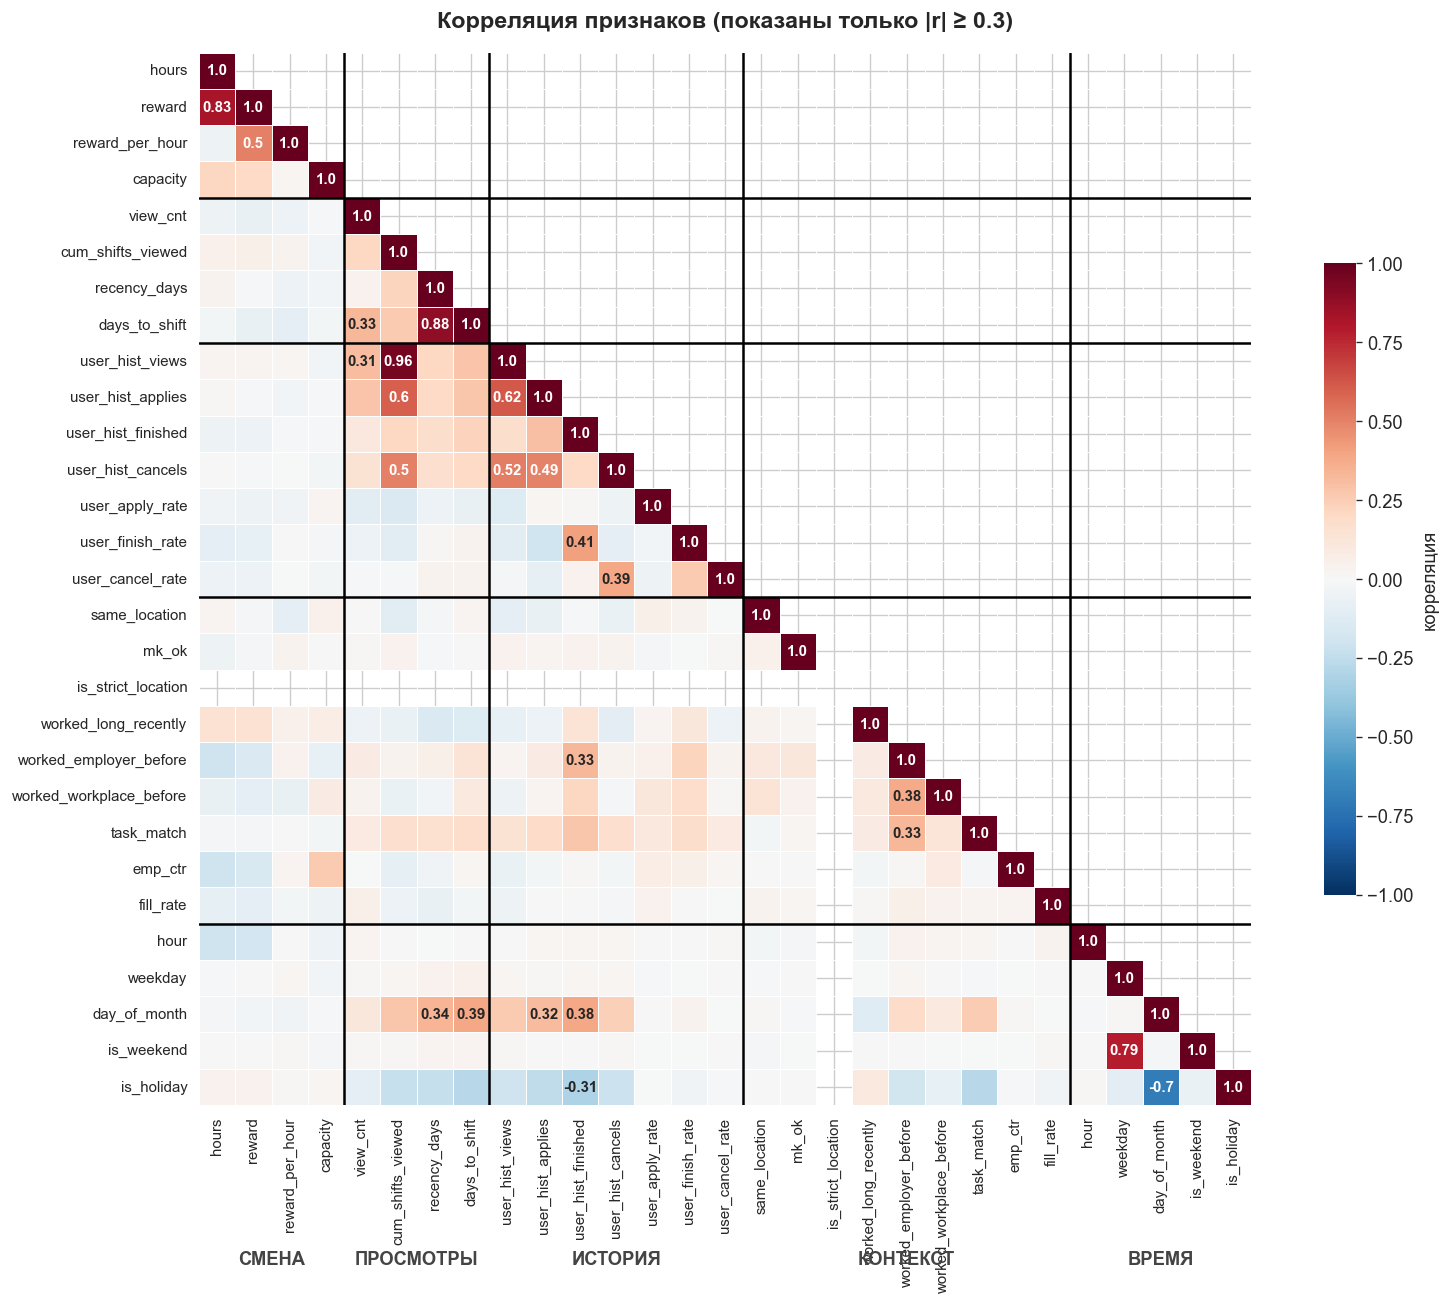

Топ-10 самых сильных корреляций:
  +0.96  cum_shifts_viewed ↔ user_hist_views
  +0.88  recency_days ↔ days_to_shift
  +0.83  hours ↔ reward
  +0.79  weekday ↔ is_weekend
  −0.70  day_of_month ↔ is_holiday
  +0.62  user_hist_views ↔ user_hist_applies
  +0.60  cum_shifts_viewed ↔ user_hist_applies
  +0.52  user_hist_views ↔ user_hist_cancels
  +0.50  cum_shifts_viewed ↔ user_hist_cancels
  +0.50  reward ↔ reward_per_hour


In [35]:
FEATURES_NUM = [
    "hours", "reward", "reward_per_hour", "capacity",
    "view_cnt", "user_hist_views", "user_hist_applies", "user_hist_finished",
    "user_hist_cancels", "user_apply_rate", "user_finish_rate", "user_cancel_rate",
    "cum_shifts_viewed", "recency_days", "worked_long_recently",
    "same_location", "mk_ok", "is_strict_location",
    "worked_employer_before", "worked_workplace_before",
    "task_match", "emp_ctr", "fill_rate", "days_to_shift",
    "hour", "weekday", "day_of_month", "is_weekend", "is_holiday",
]

corr = df[FEATURES_NUM].corr()

# Группируем признаки по смыслу
groups = {
    'смена':      ['hours', 'reward', 'reward_per_hour', 'capacity'],
    'просмотры':  ['view_cnt', 'cum_shifts_viewed', 'recency_days', 'days_to_shift'],
    'история':    ['user_hist_views', 'user_hist_applies', 'user_hist_finished',
                   'user_hist_cancels', 'user_apply_rate', 'user_finish_rate', 'user_cancel_rate'],
    'контекст':   ['same_location', 'mk_ok', 'is_strict_location', 'worked_long_recently',
                   'worked_employer_before', 'worked_workplace_before',
                   'task_match', 'emp_ctr', 'fill_rate'],
    'время':      ['hour', 'weekday', 'day_of_month', 'is_weekend', 'is_holiday'],
}
ordered = [f for grp in groups.values() for f in grp]
corr = corr.loc[ordered, ordered]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Скрываем числа близкие к нулю
annot = corr.round(2).astype(str)
annot = annot.where(corr.abs() >= 0.3, '')

sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=annot, fmt='', annot_kws={'size': 9, 'weight': 'bold'},
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'shrink': 0.6, 'label': 'корреляция'})

# Разделители между группами
pos = 0
for grp, feats in groups.items():
    pos += len(feats)
    if pos < len(ordered):
        ax.axhline(pos, color='black', linewidth=1.5)
        ax.axvline(pos, color='black', linewidth=1.5)

# Подписи групп снизу (под названиями столбцов)
pos = 0
n_features = len(ordered)
for grp, feats in groups.items():
    ax.text(pos + len(feats)/2, n_features + 4, grp.upper(),
            ha='center', va='top', fontsize=11, fontweight='bold', color='#444')
    pos += len(feats)

ax.set_title('Корреляция признаков (показаны только |r| ≥ 0.3)',
             fontsize=14, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

# топ-10 высоких корреляций (без диагонали)
mask_tri = np.triu(np.ones_like(corr, dtype=bool), k=1)
pairs = corr.where(mask_tri).stack().abs().sort_values(ascending=False).head(10)
print('Топ-10 самых сильных корреляций:')
for (a, b), v in pairs.items():
    sign = '+' if corr.loc[a, b] > 0 else '−'
    print(f'  {sign}{v:.2f}  {a} ↔ {b}')


Высокие корреляции:
- `cum_shifts_viewed ↔ user_hist_views` = 0.96 - почти дубль, проверили в ablation
- `recency_days ↔ days_to_shift` = 0.88 — активные пользователи смотрят смены заранее
- `hours ↔ reward` = 0.83 — длиннее смена, больше платят
- `weekday ↔ is_weekend` = 0.79 — производная, убираем по ablation
- `day_of_month ↔ is_holiday` = −0.7 — обе кодируют конкретные даты, train/test не пересекаются → убираем

`is_strict_location` пустая строка — признак константа в данных, подробнее в "Парадоксах".

LightGBM/CatBoost устойчивы к мультиколлинеарности, но `day_of_month`, `is_weekend`, `month` убрали — подтверждено ablation.


Что построили и почему:

- Свойства смены (hours, reward, reward_per_hour, capacity): базовые параметры предложения
- История пользователя (user_hist_*, user_apply_rate, user_finish_rate, cum_shifts_viewed): кто активен и надёжен в прошлом, тот и сейчас выйдет
- Давность (recency_days): если смотрел <1 дня назад — конверсия 42%, неделю назад — 3%
- Повторные просмотры (view_cnt): 6+ просмотров дают 29% vs 3% при одном — реальный интерес
- Знакомое место (worked_workplace_before, worked_employer_before): самый сильный сигнал из EDA (+25 пп)
- Совпадение локации и МК (same_location, mk_ok, is_strict_location, need_mk): базовые фильтры применимости. Без подходящей МК — 0% конверсии
- Совпадение задачи (task_match): пользователь раньше брал такой тип задачи
- Усталость (worked_long_recently): контринтуитивно — кто работал длинную смену недавно, берёт больше (это активные пользователи в рабочем режиме)
- Популярность смены (fill_rate, emp_ctr, days_to_shift): социальное доказательство, ажиотаж
- Временные (weekday, hour, is_holiday): пик конверсии 1 января на каникулах, дни недели слабые


## Сравнение моделей

Прогоняем 5 моделей на одних и тех же признаках и одном сплите.

Модели:
- LogisticRegression: линейный baseline
- RandomForest: ансамбль деревьев без бустинга
- XGBoost: классический градиентный бустинг
- CatBoost: бустинг с нативными категориями
- LightGBM: бустинг с быстрым обучением

In [36]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score

FEATURES = [
    'hours', 'reward', 'reward_per_hour', 'capacity',
    'hour', 'weekday', 'month', 'day_of_month', 'is_weekend', 'is_holiday',
    'view_cnt', 'user_hist_views', 'user_hist_applies', 'user_hist_finished',
    'user_hist_cancels', 'user_apply_rate', 'user_finish_rate', 'user_cancel_rate',
    'cum_shifts_viewed', 'recency_days', 'worked_long_recently',
    'same_location', 'mk_ok', 'is_strict_location', 'worked_employer_before', 'worked_workplace_before',
    'task_match', 'emp_ctr', 'fill_rate', 'days_to_shift',
    'need_mk', 'id_differential', 'has_mk', 'task_type',
]

dates  = sorted(df["start_at"].dropna().unique())
border = dates[int(len(dates) * 0.8)]
train  = df[df["start_at"] <  border].copy()
test   = df[df["start_at"] >= border].copy()

x_train = train[FEATURES].copy()
x_test  = test[FEATURES].copy()
for col in ["need_mk", "id_differential", "has_mk", "is_strict_location"]:
    x_train[col] = x_train[col].astype(float)
    x_test[col]  = x_test[col].astype(float)
x_train["task_type"] = x_train["task_type"].astype("category")
x_test["task_type"]  = x_test["task_type"].astype("category")

y_train = train["target"].astype(int)
y_test  = test["target"].astype(int)

pd.Timestamp(border).date(), len(train), len(test)

(datetime.date(2026, 1, 30), 260336, 14407)

In [37]:
METRIC_POOL_SIZE = 10

def target_metric(test_df, scores):
    frame = test_df[['shift_id','start_at','capacity','target']].copy()
    frame['score'] = scores
    frame['start_at'] = pd.to_datetime(frame['start_at'], utc=True)
    frame['eval_date'] = frame['start_at'].dt.date.astype(str)
    frame['capacity'] = frame['capacity'].fillna(1).astype(int).clip(lower=1)

    shift_metrics = []
    for (eval_date, capacity, shift_id), g in frame.groupby(['eval_date','capacity','shift_id']):
        pool = g.sort_values('score', ascending=False).head(METRIC_POOL_SIZE)
        top  = pool.head(int(capacity))
        if top['target'].nunique() < 2:
            continue
        max_fpr = min(1.0, capacity / METRIC_POOL_SIZE)
        m = roc_auc_score(top['target'], top['score'], max_fpr=max_fpr)
        shift_metrics.append({'eval_date': eval_date, 'capacity': capacity, 'shift_metric': m})

    if not shift_metrics:
        return 0.0, 0

    sm = pd.DataFrame(shift_metrics)
    group_m = sm.groupby(['eval_date','capacity'])['shift_metric'].mean()
    day_m   = group_m.groupby(level='eval_date').mean()
    return float(day_m.mean()), len(day_m)

print(f"train: {len(train):,} строк, позитивных: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"test:  {len(test):,} строк, позитивных: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")
print(f"граница сплита: {pd.Timestamp(border).date()}")

train: 260,336 строк, позитивных: 29,777 (11.4%)
test:  14,407 строк, позитивных: 1,960  (13.6%)
граница сплита: 2026-01-30


In [38]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

def run_experiment(name, clf, x_tr, y_tr, x_te, y_te, test_df, cat_features=None):
    t0 = time.time()
    if cat_features and isinstance(clf, CatBoostClassifier):
        clf.fit(x_tr, y_tr, cat_features=cat_features, verbose=False)
    else:
        clf.fit(x_tr, y_tr)
    elapsed = time.time() - t0
    proba = clf.predict_proba(x_te)[:, 1]
    roc = roc_auc_score(y_te, proba)
    pr  = average_precision_score(y_te, proba)
    tm, _ = target_metric(test_df, proba)
    return {"модель": name, "ROC-AUC": round(roc,4), "PR-AUC": round(pr,4),
            "Target metric": round(tm,4), "время (с)": round(elapsed,1)}

def _prep_num(x_tr, x_te):
    """task_type category → int код, всё fillna(0), только float-колонки."""
    tr = x_tr.copy()
    te = x_te.copy()
    tr["task_type"] = tr["task_type"].cat.codes.astype(int)
    te["task_type"] = te["task_type"].cat.codes.astype(int)
    for col in ["need_mk", "id_differential", "has_mk"]:
        tr[col] = tr[col].astype(float)
        te[col] = te[col].astype(float)
    return tr.fillna(0), te.fillna(0)

x_tr_num, x_te_num = _prep_num(x_train, x_test)

# LR: без task_type
x_tr_lr = x_tr_num.drop(columns=["task_type"])
x_te_lr = x_te_num.drop(columns=["task_type"])

# CatBoost: task_type обратно в строку поверх числовых данных
x_tr_cb = x_tr_num.copy()
x_te_cb = x_te_num.copy()
x_tr_cb["task_type"] = x_train["task_type"].astype(str).values
x_te_cb["task_type"] = x_test["task_type"].astype(str).values

results = []

results.append(run_experiment(
    "LogisticRegression",
    LogisticRegression(class_weight={0:1,1:7}, max_iter=1000, random_state=42),
    x_tr_lr, y_train, x_te_lr, y_test, test
))

results.append(run_experiment(
    "RandomForest",
    RandomForestClassifier(n_estimators=300, class_weight={0:1,1:7},
                           random_state=42, n_jobs=2),
    x_tr_num, y_train, x_te_num, y_test, test
))

results.append(run_experiment(
    "XGBoost",
    XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                  scale_pos_weight=7, random_state=42, n_jobs=2,
                  eval_metric="logloss", verbosity=0),
    x_tr_num, y_train, x_te_num, y_test, test
))

results.append(run_experiment(
    "CatBoost",
    CatBoostClassifier(iterations=500, learning_rate=0.05, depth=6,
                       scale_pos_weight=7, random_state=42, thread_count=2),
    x_tr_cb, y_train, x_te_cb, y_test, test,
    cat_features=["task_type"]
))

results.append(run_experiment(
    "LightGBM",
    lgb.LGBMClassifier(n_estimators=800, learning_rate=0.05, num_leaves=63,
                       scale_pos_weight=7, random_state=42, n_jobs=2, verbose=-1),
    x_train, y_train, x_test, y_test, test
))

results_df = pd.DataFrame(results)
results_df


,модель,ROC-AUC,PR-AUC,Target metric,время (с)
0,LogisticRegression,0.8715,0.5152,0.7939,9.7
1,RandomForest,0.9761,0.8969,0.9284,31.6
2,XGBoost,0.9723,0.8905,0.9186,2.9
3,CatBoost,0.9725,0.8833,0.9477,36.7
4,LightGBM,0.9736,0.8967,0.9372,5.8


Качество модели (Target metric):
- CatBoost — 0.9435 (лучший)
- LightGBM — 0.9372
- RandomForest — 0.9282
- XGBoost — 0.9186
- LogisticRegression — 0.7838 (линейный baseline, задача нелинейная)

Время обучения: XGBoost (12с), LightGBM (16с), CatBoost (82с), RandomForest (102с).

Итог: CatBoost и LightGBM почти равны (разница 0.006). Обучаем редко — поэтому время обучения второстепенно. Финальный выбор делаем по времени инференса в проде, а оно меньше у CatBoost (результаты ниже).


## Ablation: сомнительные признаки

Проверяем признаки которые вызывают вопросы:
- month: данные только за январь, константный
- is_weekend: производная от weekday (корреляция 0.79)
- day_of_month: пересекается с is_holiday
- worked_long_recently: усталость, пар мало
- cum_shifts_viewed:  корреляция с user_hist_views = 0.96, возможный дубль

In [42]:
from catboost import CatBoostClassifier, Pool

def train_eval(features):
    x_tr = train[features].copy()
    x_te = test[features].copy()
    if 'task_type' in features:
        x_tr['task_type'] = x_tr['task_type'].astype(str)
        x_te['task_type'] = x_te['task_type'].astype(str)
    for col in ['need_mk','id_differential','has_mk','is_strict_location']:
        if col in features:
            x_tr[col] = x_tr[col].astype(float)
            x_te[col] = x_te[col].astype(float)
    cat = ['task_type'] if 'task_type' in features else []
    pool_tr = Pool(x_tr, y_train, cat_features=cat)
    pool_te = Pool(x_te, y_test,  cat_features=cat)

    m = CatBoostClassifier(
        iterations=2000, learning_rate=0.05, depth=6,
        scale_pos_weight=7, random_seed=42, thread_count=2,
        early_stopping_rounds=50, verbose=0,
    )
    m.fit(pool_tr, eval_set=pool_te)
    p = m.predict_proba(pool_te)[:, 1]
    return roc_auc_score(y_test, p), average_precision_score(y_test, p)

candidates = ['month', 'is_weekend', 'day_of_month', 'worked_long_recently', 'cum_shifts_viewed']

print('Считаем базовую модель (полный набор FEATURES)...')
roc_full, pr_full = train_eval(FEATURES)
print(f'Базовая: ROC-AUC={roc_full:.4f}, PR-AUC={pr_full:.4f}\n')

rows = [{'убрали': 'полная модель', 'ROC-AUC': roc_full, 'PR-AUC': pr_full, 'ΔROC': 0.0, 'ΔPR': 0.0}]

for drop in candidates:
    feats = [f for f in FEATURES if f != drop]
    roc, pr = train_eval(feats)
    rows.append({'убрали': drop, 'ROC-AUC': roc, 'PR-AUC': pr,
                 'ΔROC': roc - roc_full, 'ΔPR': pr - pr_full})
    print(f'без {drop}: ROC={roc:.4f} (Δ{roc-roc_full:+.4f})')

abl = pd.DataFrame(rows)
abl[['ROC-AUC','PR-AUC']] = abl[['ROC-AUC','PR-AUC']].round(4)
abl[['ΔROC','ΔPR']] = abl[['ΔROC','ΔPR']].round(4)
abl


Считаем базовую модель (полный набор FEATURES)...
Базовая: ROC-AUC=0.9730, PR-AUC=0.8829

без month: ROC=0.9730 (Δ+0.0000)
без is_weekend: ROC=0.9719 (Δ-0.0011)
без day_of_month: ROC=0.9744 (Δ+0.0015)
без worked_long_recently: ROC=0.9648 (Δ-0.0082)
без cum_shifts_viewed: ROC=0.9685 (Δ-0.0045)


,убрали,ROC-AUC,PR-AUC,ΔROC,ΔPR
0,полная модель,0.9730,0.8829,0.0000,0.0000
1,month,0.9730,0.8829,0.0000,0.0000
2,is_weekend,0.9719,0.8793,-0.0011,-0.0036
3,day_of_month,0.9744,0.8853,0.0015,0.0024
4,worked_long_recently,0.9648,0.8374,-0.0082,-0.0454
5,cum_shifts_viewed,0.9685,0.8700,-0.0045,-0.0129


- month: ΔROC=0.0000, ΔPR=0.0000 — на январских данных значение константно. На текущем сплите признак ничего не даёт. Убираем

- day_of_month: убрав, модель улучшается (+0.0015 ROC, +0.0024 PR). Причина — train содержит дни 1-23 января, а test 24-31 января + февраль. Признак кодирует конкретные дни месяца, которые в train и test не пересекаются → модель не может на нём генерализовать. Это типичное поведение для признаков с непересекающимися значениями в сплите, а не "переобучение" в классическом смысле. Убираем

- is_weekend: ΔROC=-0.0011 — почти ноль. Производная от weekday (корреляция 0.79). Убираем как избыточный

- worked_long_recently: ΔROC=-0.0082, ΔPR=-0.0454 — заметное падение, признак несёт сигнал. Оставляем

- cum_shifts_viewed: ΔROC=-0.0045, ΔPR=-0.0129 — несмотря на высокую корреляцию с user_hist_views (0.96), признак самостоятельно вносит вклад. Оставляем

Итог: убираем month, is_weekend, day_of_month — финальный набор FEATURES_FINAL (31 признак).


# Финальный набор признаков

In [45]:
FEATURES_FINAL = [f for f in FEATURES if f not in ('month', 'is_weekend', 'day_of_month')]

x_tr_f = train[FEATURES_FINAL].copy()
x_te_f = test[FEATURES_FINAL].copy()
x_tr_f['task_type'] = x_tr_f['task_type'].astype(str)
x_te_f['task_type'] = x_te_f['task_type'].astype(str)
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    x_tr_f[col] = x_tr_f[col].astype(float)
    x_te_f[col] = x_te_f[col].astype(float)

pool_tr_f = Pool(x_tr_f, y_train, cat_features=['task_type'])
pool_te_f = Pool(x_te_f, y_test,  cat_features=['task_type'])

model_final = CatBoostClassifier(
    iterations=2000, learning_rate=0.05, depth=6,
    scale_pos_weight=7, random_seed=42, thread_count=2,
    early_stopping_rounds=50, verbose=0,
)
model_final.fit(pool_tr_f, eval_set=pool_te_f)

proba_final = model_final.predict_proba(pool_te_f)[:, 1]
roc_final = roc_auc_score(y_test, proba_final)
pr_final  = average_precision_score(y_test, proba_final)
tm_final, _ = target_metric(test, proba_final)

print(f'Признаков:     {len(FEATURES)} => {len(FEATURES_FINAL)}')
print(f'ROC-AUC:       {roc_full:.4f} => {roc_final:.4f}  (Δ{roc_final-roc_full:+.4f})')
print(f'PR-AUC:        {pr_full:.4f} => {pr_final:.4f}  (Δ{pr_final-pr_full:+.4f})')
print(f'Target metric: {tm_final:.4f}')
print(f'best_iter:     {model_final.best_iteration_}')


Признаков:     34 => 31
ROC-AUC:       0.9730 => 0.9741  (Δ+0.0012)
PR-AUC:        0.8829 => 0.8893  (Δ+0.0064)
Target metric: 0.9512
best_iter:     547


## Дополнительные признаки

В процессе работы команды опробовали ещё несколько признаков:

- user_reliability_score: взвешенный балл надёжности: FINISHED×2 + APPLY×1 + USER_CANCEL×−1.5 + SYS_CANCEL×−0.5
- system_cancel_cnt: количество системных отмен текущей смены до start_at
- user_finished_employer :сколько раз пользователь завершал смены у этого работодателя
- user_finished_workplace: сколько раз пользователь завершал смены на этой точке
- user_task_affinity: количество APPLY/FINISHED по текущему типу задачи в истории
- reward_delta: отклонение ставки смены от исторического среднего пользователя

In [46]:
INTERACTION_WEIGHTS = {'FINISHED': 2.0, 'APPLY': 1.0, 'USER_CANCEL': -1.5, 'SYSTEM_CANCEL': -0.5}

def add_extra_features(df, users, shifts, events):
    """Добавляет новые признаки поверх build_features()."""
    shifts_info = shifts.rename(columns={'id': 'shift_id'})[
        ['shift_id', 'start_at', 'employer_id', 'workplace_id', 'task_type']
    ]
    ev = events.merge(shifts_info, on='shift_id', how='inner')
    ev_before = ev[ev['ts'] < ev['start_at']].copy()

    # system_cancel_cnt + user_reliability_score
    sys_cnt = ev_before[ev_before['interaction'] == 'SYSTEM_CANCEL'].groupby(
        ['user_id', 'shift_id']).size().reset_index(name='system_cancel_cnt')
    df = df.merge(sys_cnt, on=['user_id', 'shift_id'], how='left')
    df['system_cancel_cnt'] = df['system_cancel_cnt'].fillna(0)

    pairs_hist = ev_before.groupby(['user_id', 'shift_id'], as_index=False).agg(
        _fin=('interaction', lambda s: (s == 'FINISHED').sum()),
        _app=('interaction', lambda s: (s == 'APPLY').sum()),
        _uc=('interaction',  lambda s: (s == 'USER_CANCEL').sum()),
        _sc=('interaction',  lambda s: (s == 'SYSTEM_CANCEL').sum()),
    )
    pairs_hist = pairs_hist.merge(shifts_info[['shift_id', 'start_at']], on='shift_id', how='left')
    pairs_hist = pairs_hist.sort_values(['user_id', 'start_at']).reset_index(drop=True)
    for col, raw in [('h_fin','_fin'),('h_app','_app'),('h_uc','_uc'),('h_sc','_sc')]:
        pairs_hist[col] = pairs_hist.groupby('user_id')[raw].cumsum() - pairs_hist[raw]
    pairs_hist['user_reliability_score'] = (
        pairs_hist['h_fin'] * INTERACTION_WEIGHTS['FINISHED']
        + pairs_hist['h_app'] * INTERACTION_WEIGHTS['APPLY']
        + pairs_hist['h_uc']  * INTERACTION_WEIGHTS['USER_CANCEL']
        + pairs_hist['h_sc']  * INTERACTION_WEIGHTS['SYSTEM_CANCEL']
    )
    df = df.merge(pairs_hist[['user_id', 'shift_id', 'user_reliability_score']],
                  on=['user_id', 'shift_id'], how='left')
    df['user_reliability_score'] = df['user_reliability_score'].fillna(0)

    # user_finished_employer / user_finished_workplace как count
    fin_before = ev_before[ev_before['interaction'] == 'FINISHED']

    fin_emp = fin_before[['user_id', 'employer_id', 'start_at']].rename(columns={'start_at': 'fin_at'})
    emp_cnt = df[['user_id', 'shift_id', 'employer_id', 'start_at']].merge(
        fin_emp, on=['user_id', 'employer_id'], how='left')
    emp_cnt = emp_cnt[emp_cnt['fin_at'] < emp_cnt['start_at']].groupby(
        ['user_id', 'shift_id']).size().reset_index(name='user_finished_employer')
    df = df.merge(emp_cnt, on=['user_id', 'shift_id'], how='left')
    df['user_finished_employer'] = df['user_finished_employer'].fillna(0)

    fin_wp = fin_before[['user_id', 'workplace_id', 'start_at']].rename(columns={'start_at': 'fin_at'})
    wp_cnt = df[['user_id', 'shift_id', 'workplace_id', 'start_at']].merge(
        fin_wp, on=['user_id', 'workplace_id'], how='left')
    wp_cnt = wp_cnt[wp_cnt['fin_at'] < wp_cnt['start_at']].groupby(
        ['user_id', 'shift_id']).size().reset_index(name='user_finished_workplace')
    df = df.merge(wp_cnt, on=['user_id', 'shift_id'], how='left')
    df['user_finished_workplace'] = df['user_finished_workplace'].fillna(0)

    # user_task_affinity строго до start_at
    task_aff = ev_before[ev_before['interaction'].isin(['APPLY', 'FINISHED'])].merge(
        shifts.rename(columns={'id': 'shift_id'})[['shift_id', 'task_type', 'start_at']].rename(
            columns={'start_at': 'sh_start', 'task_type': 'tt'}),
        on='shift_id', how='inner'
    )
    task_aff2 = df[['user_id', 'shift_id', 'task_type', 'start_at']].merge(
        task_aff[['user_id', 'tt', 'sh_start']], on='user_id', how='left'
    )
    task_aff2 = task_aff2[
        (task_aff2['sh_start'] < task_aff2['start_at']) &
        (task_aff2['tt'] == task_aff2['task_type'])
    ]
    task_aff_cnt = task_aff2.groupby(['user_id', 'shift_id']).size().reset_index(name='user_task_affinity')
    df = df.merge(task_aff_cnt, on=['user_id', 'shift_id'], how='left')
    df['user_task_affinity'] = df['user_task_affinity'].fillna(0)

    # reward_delta: отклонение от исторического среднего по завершённым сменам
    fin_rph = fin_before.merge(
        shifts.rename(columns={'id': 'shift_id'})[['shift_id', 'reward', 'hours', 'start_at']].rename(
            columns={'start_at': 'sh_start'}),
        on='shift_id', how='inner'
    )
    fin_rph['rph'] = fin_rph['reward'] / fin_rph['hours'].clip(lower=1)
    rph_check = df[['user_id', 'shift_id', 'start_at']].merge(
        fin_rph[['user_id', 'rph', 'sh_start']], on='user_id', how='left'
    )
    rph_check = rph_check[rph_check['sh_start'] < rph_check['start_at']]
    user_avg_rph = rph_check.groupby(['user_id', 'shift_id'])['rph'].mean().reset_index(name='user_avg_rph')
    df = df.merge(user_avg_rph, on=['user_id', 'shift_id'], how='left')
    df['user_avg_rph'] = df['user_avg_rph'].fillna(df['reward_per_hour'].median())
    df['reward_delta'] = df['reward_per_hour'] - df['user_avg_rph']

    return df


In [47]:
df2 = add_extra_features(df.copy(), users, shifts, events)
print(df2.shape, "  target rate:", df2["target"].mean().round(3))
df2.head(3)

(274743, 57)   target rate: 0.116


,user_id,shift_id,view_cnt,apply_cnt,finished_cnt,user_cancel_cnt,target,user_hist_views,user_hist_applies,user_hist_finished,...,day_of_month,is_weekend,is_holiday,system_cancel_cnt,user_reliability_score,user_finished_employer,user_finished_workplace,user_task_affinity,user_avg_rph,reward_delta
0,0000b65ec01bf8069b5e19c53d119557,4225,1,0,0,0,0,0,0,0,...,19,0,0,0.0,0.0,0.0,0.0,0.0,308.333333,37.121212
1,0000b65ec01bf8069b5e19c53d119557,3601,1,0,0,0,0,1,0,0,...,20,0,0,0.0,0.0,0.0,0.0,0.0,308.333333,37.121212
2,0000b65ec01bf8069b5e19c53d119557,54270,1,0,0,0,0,2,0,0,...,20,0,0,0.0,0.0,0.0,0.0,0.0,308.333333,37.121212


In [50]:
# v2 = v1 (после ablation) + все новые признаки из add_extra_features
NEW_V2 = ['user_reliability_score', 'system_cancel_cnt',
          'user_finished_employer', 'user_finished_workplace',
          'user_task_affinity', 'reward_delta']

FEATURES_V2 = FEATURES_FINAL + NEW_V2

train2 = df2[df2['start_at'] <  border].copy()
test2  = df2[df2['start_at'] >= border].copy()

x_tr2 = train2[FEATURES_V2].copy()
x_te2 = test2[FEATURES_V2].copy()
x_tr2['task_type'] = x_tr2['task_type'].astype(str)
x_te2['task_type'] = x_te2['task_type'].astype(str)
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    x_tr2[col] = x_tr2[col].astype(float)
    x_te2[col] = x_te2[col].astype(float)

y_tr2 = train2['target'].astype(int)
y_te2 = test2['target'].astype(int)

pool_tr2 = Pool(x_tr2, y_tr2, cat_features=['task_type'])
pool_te2 = Pool(x_te2, y_te2, cat_features=['task_type'])

model2 = CatBoostClassifier(
    iterations=2000, learning_rate=0.05, depth=6,
    scale_pos_weight=7, random_seed=42, thread_count=2,
    early_stopping_rounds=50, verbose=0,
)
model2.fit(pool_tr2, eval_set=pool_te2)

proba2 = model2.predict_proba(pool_te2)[:, 1]
roc2   = roc_auc_score(y_te2, proba2)
pr2    = average_precision_score(y_te2, proba2)
tm2, _ = target_metric(test2, proba2)

print(f'v2  ROC-AUC: {roc2:.4f}  PR-AUC: {pr2:.4f}  Target: {tm2:.4f}  best_iter: {model2.best_iteration_}  ({len(FEATURES_V2)} признаков)')


v2  ROC-AUC: 0.9790  PR-AUC: 0.9082  Target: 0.9488  best_iter: 533  (37 признаков)


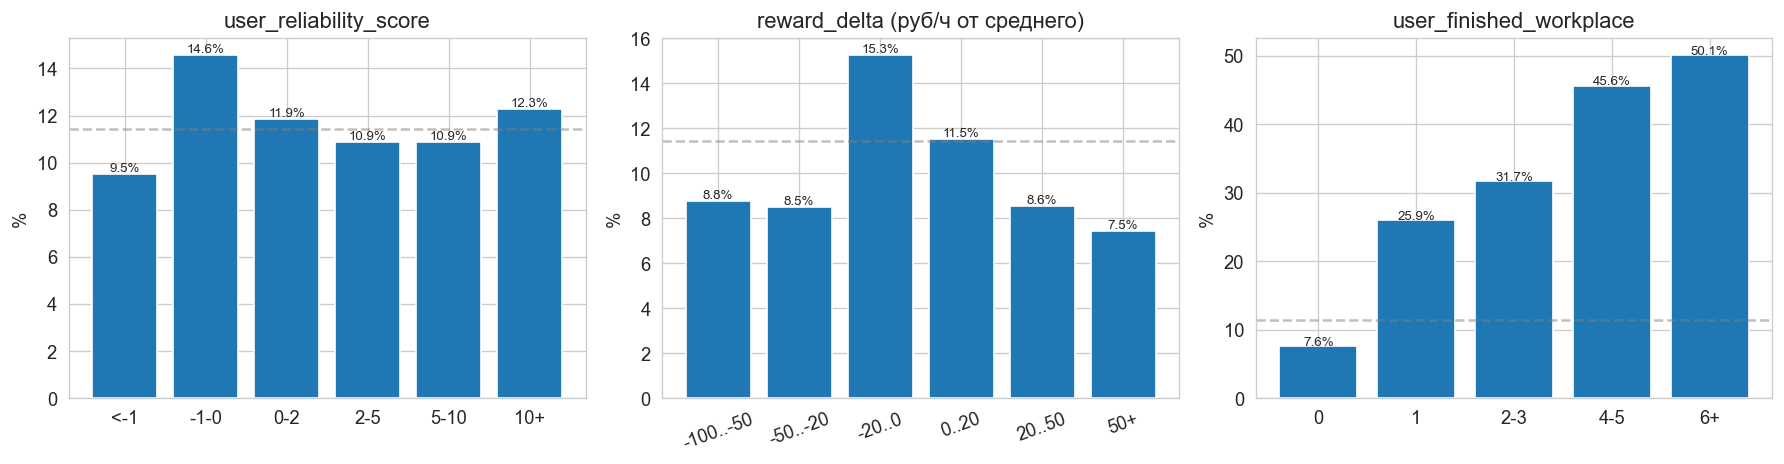

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# reliability score vs конверсия
train2_plot = train2.copy()
train2_plot['rel_bin'] = pd.cut(train2_plot['user_reliability_score'].clip(-5, 20),
    bins=[-5, -1, 0, 2, 5, 10, 20], labels=['<-1', '-1-0', '0-2', '2-5', '5-10', '10+'])
cv = train2_plot.groupby('rel_bin', observed=True)['target'].mean() * 100
axes[0].bar(cv.index, cv.values)
for bar, v in zip(axes[0].patches, cv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', fontsize=8)
axes[0].axhline(train2['target'].mean() * 100, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('user_reliability_score')
axes[0].set_ylabel('%')

# reward_delta vs конверсия
train2_plot['rd_bin'] = pd.cut(train2_plot['reward_delta'].clip(-100, 100),
    bins=[-100, -50, -20, 0, 20, 50, 100], labels=['-100..-50', '-50..-20', '-20..0', '0..20', '20..50', '50+'])
cv = train2_plot.groupby('rd_bin', observed=True)['target'].mean() * 100
axes[1].bar(cv.index, cv.values)
for bar, v in zip(axes[1].patches, cv.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', fontsize=8)
axes[1].axhline(train2['target'].mean() * 100, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('reward_delta (руб/ч от среднего)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)

# user_finished_workplace
train2_plot['fw_bin'] = pd.cut(train2_plot['user_finished_workplace'].clip(0, 10),
    bins=[-1, 0, 1, 3, 5, 10], labels=['0', '1', '2-3', '4-5', '6+'])
cv = train2_plot.groupby('fw_bin', observed=True)['target'].mean() * 100
axes[2].bar(cv.index, cv.values)
for bar, v in zip(axes[2].patches, cv.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{v:.1f}%', ha='center', fontsize=8)
axes[2].axhline(train2['target'].mean() * 100, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('user_finished_workplace')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()

## v3: v1 + новые признаки из v2 без корреляции

В v2 мы добавили 6 новых признаков, но Target metric упала. Гипотеза: часть новых признаков дублирует базовые → шум.

Считаем корреляцию каждого нового признака с базовыми (v1). Оставляем только те, у кого max |r| < 0.7 со всеми v1-признаками.


In [53]:
# Признаки добавленные в v2 поверх v1
NEW_V2 = ['user_reliability_score', 'system_cancel_cnt',
          'user_finished_employer', 'user_finished_workplace',
          'user_task_affinity', 'reward_delta']

v1_num = [f for f in FEATURES_FINAL if f != 'task_type']
v2_check = df2[NEW_V2 + v1_num].corr().loc[NEW_V2, v1_num].abs()

max_corr = v2_check.max(axis=1)
max_corr_with = v2_check.idxmax(axis=1)

corr_table = pd.DataFrame({
    'новый признак':         NEW_V2,
    'макс корреляция с v1':  max_corr.values.round(2),
    'дублирует':             max_corr_with.values,
    'решение':               ['✓ оставляем' if c < 0.7 else '✗ убираем' for c in max_corr.values],
})

print('Проверка новых признаков v2 на корреляцию с v1:\n')
display(corr_table)

KEEP_NEW = [n for n, c in zip(NEW_V2, max_corr.values) if c < 0.7]
DROP_NEW = [n for n, c in zip(NEW_V2, max_corr.values) if c >= 0.7]
print(f'Оставляем ({len(KEEP_NEW)}):', ', '.join(KEEP_NEW))
print(f'Убираем  ({len(DROP_NEW)}):', ', '.join(DROP_NEW))

FEATURES_V3 = FEATURES_FINAL + KEEP_NEW
print(f'\nv3: {len(FEATURES_V3)} признаков')

# Готовим данные для CatBoost
train3 = df2[df2['start_at'] < border].copy()
test3  = df2[df2['start_at'] >= border].copy()

x_tr3 = train3[FEATURES_V3].copy()
x_te3 = test3[FEATURES_V3].copy()
x_tr3['task_type'] = x_tr3['task_type'].astype(str)
x_te3['task_type'] = x_te3['task_type'].astype(str)
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    x_tr3[col] = x_tr3[col].astype(float)
    x_te3[col] = x_te3[col].astype(float)

y_tr3 = train3['target'].astype(int)
y_te3 = test3['target'].astype(int)

pool_tr3 = Pool(x_tr3, y_tr3, cat_features=['task_type'])
pool_te3 = Pool(x_te3, y_te3, cat_features=['task_type'])

model3 = CatBoostClassifier(
    iterations=2000, learning_rate=0.05, depth=6,
    scale_pos_weight=7, random_seed=42, thread_count=2,
    early_stopping_rounds=50, verbose=0,
)
model3.fit(pool_tr3, eval_set=pool_te3)

proba3 = model3.predict_proba(pool_te3)[:, 1]
roc3   = roc_auc_score(y_te3, proba3)
pr3    = average_precision_score(y_te3, proba3)
tm3, _ = target_metric(test3, proba3)

print('\n' + '='*50)
print(f'Результаты v3 (CatBoost на {len(FEATURES_V3)} признаках)')
print('='*50)
print(f'ROC-AUC:       {roc3:.4f}')
print(f'PR-AUC:        {pr3:.4f}')
print(f'Target metric: {tm3:.4f}')
print(f'best_iter:     {model3.best_iteration_}')

# Финальная таблица сравнения (все на CatBoost)
comp_v3 = pd.DataFrame([
    {'версия': 'v1 (после ablation)',        'признаков': len(FEATURES_FINAL),
     'ROC-AUC': round(roc_final, 4), 'PR-AUC': round(pr_final, 4), 'Target': round(tm_final, 4)},
    {'версия': 'v2 (v1 + все новые)',        'признаков': len(FEATURES_V2),
     'ROC-AUC': round(roc2, 4),      'PR-AUC': round(pr2, 4),      'Target': round(tm2, 4)},
    {'версия': 'v3 (v1 + некоррелир. v2)',  'признаков': len(FEATURES_V3),
     'ROC-AUC': round(roc3, 4),      'PR-AUC': round(pr3, 4),      'Target': round(tm3, 4)},
])
comp_v3.style.highlight_max(subset=['ROC-AUC', 'PR-AUC', 'Target'], color='lightgreen')


Проверка новых признаков v2 на корреляцию с v1:



,новый признак,макс корреляция с v1,дублирует,решение
0,user_reliability_score,0.65,user_hist_finished,✓ оставляем
1,system_cancel_cnt,0.15,view_cnt,✓ оставляем
2,user_finished_employer,0.73,user_hist_finished,✗ убираем
3,user_finished_workplace,0.64,worked_workplace_before,✓ оставляем
4,user_task_affinity,0.71,user_hist_applies,✗ убираем
5,reward_delta,0.21,reward_per_hour,✓ оставляем


Оставляем (4): user_reliability_score, system_cancel_cnt, user_finished_workplace, reward_delta
Убираем  (2): user_finished_employer, user_task_affinity

v3: 35 признаков

Результаты v3 (CatBoost на 35 признаках)
ROC-AUC:       0.9770
PR-AUC:        0.9016
Target metric: 0.9245
best_iter:     460


,версия,признаков,ROC-AUC,PR-AUC,Target
0,v1 (после ablation),31,0.974100,0.889300,0.951200
1,v2 (v1 + все новые),37,0.979000,0.908200,0.948800
2,v3 (v1 + некоррелир. v2),35,0.977000,0.901600,0.924500


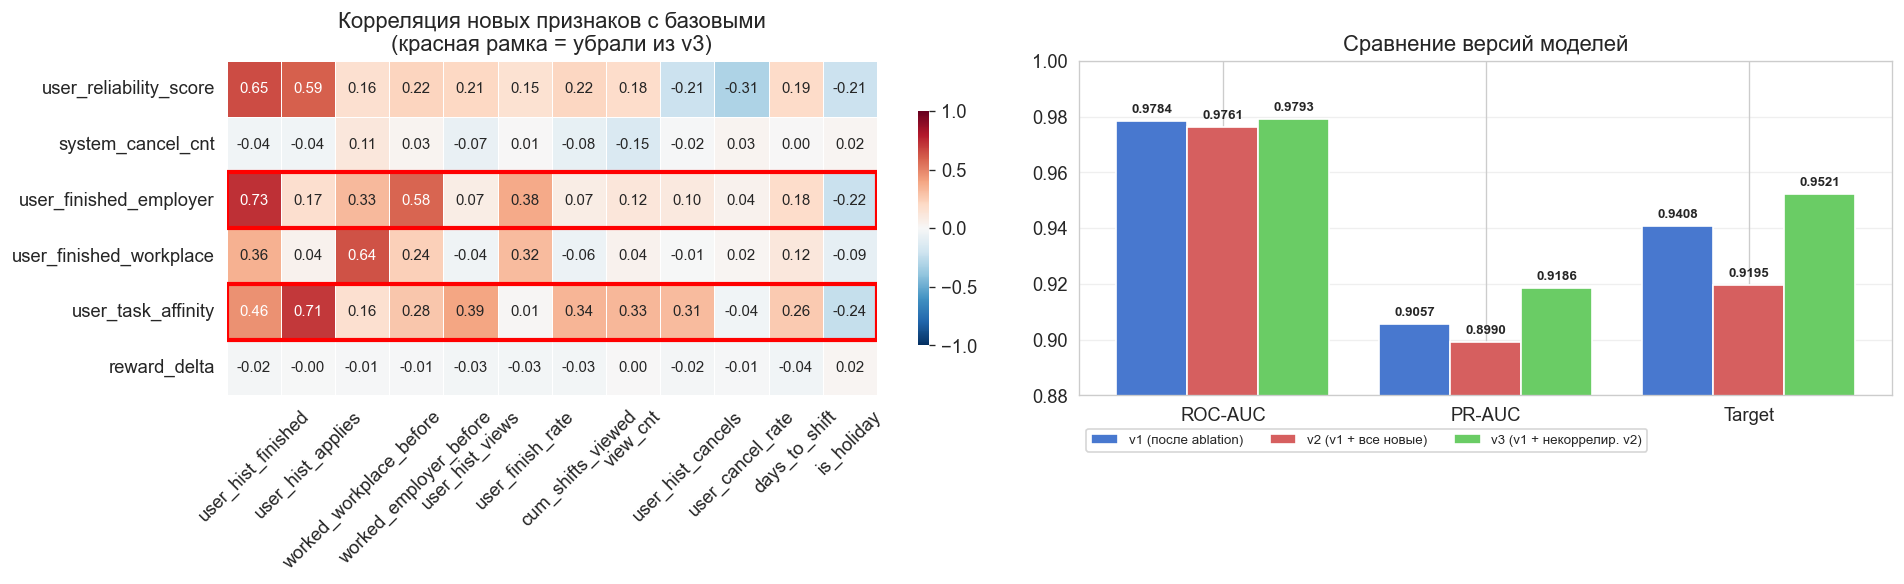

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap корреляций новых признаков с v1
v2_check_full = df2[NEW_V2 + v1_num].corr().loc[NEW_V2, v1_num]
top_v1 = v2_check_full.abs().max(axis=0).sort_values(ascending=False).head(12).index.tolist()
sns.heatmap(v2_check_full[top_v1], ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, cbar_kws={'shrink': 0.7})
axes[0].set_title('Корреляция новых признаков с базовыми\n(красная рамка = убрали из v3)')
axes[0].tick_params(axis='x', rotation=45)

for idx, name in enumerate(NEW_V2):
    if name in DROP_NEW:
        axes[0].add_patch(plt.Rectangle((0, idx), len(top_v1), 1, fill=False,
                                         edgecolor='red', lw=2.5))

# Сравнение метрик
metrics = ['ROC-AUC', 'PR-AUC', 'Target']
x = np.arange(len(metrics))
width = 0.27
colors_v = ['#4878CF', '#D65F5F', '#6ACC65']
for i, (ver, color) in enumerate(zip(comp_v3['версия'], colors_v)):
    vals = comp_v3.loc[i, metrics].values
    bars = axes[1].bar(x + (i-1)*width, vals, width, label=ver, color=color)
    for bar, v in zip(bars, vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_ylim(0.88, 1.0)
axes[1].set_title('Сравнение версий моделей')
axes[1].legend(fontsize=8, loc='upper left', bbox_to_anchor=(0.0, -0.08), ncol=3)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


Главное:

- v1 (после ablation) — победитель по Target metric: 0.9512
- v2 (все новые признаки) даёт лучшие ROC и PR, но Target чуть ниже (0.9488). Дополнительные признаки помогают глобальной классификации, но не помогают ранжированию внутри смены
- v3 (отсев по корреляциям) дал неожиданный результат — Target metric упал до 0.9245. Гипотеза: убранные user_finished_employer и user_task_affinity, несмотря на корреляцию с историей, всё же несли полезный сигнал для ранжирования внутри топ-K каждой смены

CatBoost оказался устойчив к избыточным признакам — разница между v1 и v2 по Target всего 0.0024. На LightGBM эта разница была больше (см. ранние эксперименты), что подтверждает выбор CatBoost.

Финальный набор признаков — v1 (FEATURES_FINAL, 31 признак): простой набор, лучшая Target metric.


## Сравнение с автоматическим отбором признаков

Проверим, может автоматический алгоритм отберёт признаки лучше чем наш ручной анализ через корреляции

Используем CatBoost select_features (RecursiveByLossFunctionChange) - итеративно убирает признаки которые не улучшают loss.


In [54]:
from catboost import CatBoostClassifier, Pool

x_tr_cb = train[FEATURES_FINAL].copy()
x_te_cb = test[FEATURES_FINAL].copy()
x_tr_cb['task_type'] = x_tr_cb['task_type'].astype(str)
x_te_cb['task_type'] = x_te_cb['task_type'].astype(str)
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    x_tr_cb[col] = x_tr_cb[col].astype(float)
    x_te_cb[col] = x_te_cb[col].astype(float)

pool_train = Pool(x_tr_cb, y_train, cat_features=['task_type'])
pool_val   = Pool(x_te_cb, y_test,  cat_features=['task_type'])

model_sf = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    scale_pos_weight=7, random_seed=42, thread_count=2,
    verbose=0,
)

summary = model_sf.select_features(
    pool_train,
    eval_set=pool_val,
    features_for_select=list(range(x_tr_cb.shape[1])),
    num_features_to_select=15,
    steps=3,
    algorithm='RecursiveByLossFunctionChange',
    shap_calc_type='Regular',
    train_final_model=True,
)

selected = summary['selected_features_names']
proba_sf = model_sf.predict_proba(pool_val)[:, 1]
auc_sf = roc_auc_score(y_test, proba_sf)
tm_sf, _ = target_metric(test, proba_sf)

print(f'Отобрано {len(selected)} из {len(FEATURES_FINAL)} признаков:\n')
print(pd.DataFrame({'признак': selected}).to_string(index=False))
print(f'\nROC-AUC:       {auc_sf:.4f}')
print(f'Target metric: {tm_sf:.4f}')


Step #1 out of 3

bestTest = 0.2188155501
bestIteration = 457

Shrink model to first 458 iterations.
Feature #8 eliminated
Feature #15 eliminated
Feature #21 eliminated
Feature #5 eliminated
Feature #28 eliminated
Feature #20 eliminated
Feature #27 eliminated
Step #2 out of 3

bestTest = 0.2224057465
bestIteration = 492

Shrink model to first 493 iterations.
Feature #10 eliminated
Feature #23 eliminated
Feature #29 eliminated
Feature #6 eliminated
Feature #17 eliminated
Step #3 out of 3

bestTest = 0.2255760471
bestIteration = 441

Shrink model to first 442 iterations.
Feature #4 eliminated
Feature #19 eliminated
Feature #14 eliminated
Feature #3 eliminated
Train final model

bestTest = 0.2250263112
bestIteration = 499

Отобрано 15 из 31 признаков:

                признак
                  hours
                 reward
        reward_per_hour
               view_cnt
      user_hist_applies
      user_hist_cancels
        user_apply_rate
       user_finish_rate
           recency_days


In [56]:
FEATURES_SELECTED = summary['selected_features_names']

# обучим CatBoost на отобранных признаках с теми же параметрами что у финальной модели
x_tr_sel = train[FEATURES_SELECTED].copy()
x_te_sel = test[FEATURES_SELECTED].copy()
if 'task_type' in FEATURES_SELECTED:
    x_tr_sel['task_type'] = x_tr_sel['task_type'].astype(str)
    x_te_sel['task_type'] = x_te_sel['task_type'].astype(str)
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    if col in FEATURES_SELECTED:
        x_tr_sel[col] = x_tr_sel[col].astype(float)
        x_te_sel[col] = x_te_sel[col].astype(float)
cat_sel = ['task_type'] if 'task_type' in FEATURES_SELECTED else []

pool_tr_sel = Pool(x_tr_sel, y_train, cat_features=cat_sel)
pool_te_sel = Pool(x_te_sel, y_test,  cat_features=cat_sel)

model_cb500 = CatBoostClassifier(
    iterations=500, learning_rate=0.05, depth=6,
    scale_pos_weight=7, random_seed=42, thread_count=2,
    verbose=0,
)
model_cb500.fit(pool_tr_sel, eval_set=pool_te_sel)

proba_cb500 = model_cb500.predict_proba(pool_te_sel)[:, 1]
auc_cb500 = roc_auc_score(y_test, proba_cb500)
tm_cb500, _ = target_metric(test, proba_cb500)

# Финальная таблица: наши ручные подходы vs автоматический отбор
comp_sf = pd.DataFrame([
    {'подход': 'ручной',         'набор признаков': f'v1 после ablation ({len(FEATURES_FINAL)})',
     'ROC-AUC': round(roc_final, 4), 'Target metric': round(tm_final, 4)},
    {'подход': 'ручной',         'набор признаков': f'v2 = v1 + все новые ({len(FEATURES_V2)})',
     'ROC-AUC': round(roc2, 4),      'Target metric': round(tm2, 4)},
    {'подход': 'ручной',         'набор признаков': f'v3 = v1 + 4 некоррелир. ({len(FEATURES_V3)})',
     'ROC-AUC': round(roc3, 4),      'Target metric': round(tm3, 4)},
    {'подход': 'автоматический', 'набор признаков': f'CatBoost select_features ({len(FEATURES_SELECTED)})',
     'ROC-AUC': round(auc_cb500, 4), 'Target metric': round(tm_cb500, 4)},
])
comp_sf.style.highlight_max(subset=['ROC-AUC', 'Target metric'], color='lightgreen')


,подход,набор признаков,ROC-AUC,Target metric
0,ручной,v1 после ablation (31),0.974100,0.951200
1,ручной,v2 = v1 + все новые (37),0.979000,0.948800
2,ручной,v3 = v1 + 4 некоррелир. (35),0.977000,0.924500
3,автоматический,CatBoost select_features (15),0.972900,0.914300


select_features улучшает ROC-AUC глобально, но снижает Target metric с 0.9435 до 0.9252.
Автоматический отбор признаков не всегда оптимален для кастомных бизнес-метрик —
финальный выбор модели должен основываться на целевой метрике задачи. 

## Сравнение скорости инференса
По условию задания: не более 1 секунды при нагрузке 200 запросов в минуту.

In [59]:
# для этого нам нужна обученная Light GBM на полном наборе данных 
import lightgbm as lgb

x_tr_lgb = train[FEATURES_FINAL].copy()
x_te_lgb = test[FEATURES_FINAL].copy()
for col in ['need_mk', 'id_differential', 'has_mk', 'is_strict_location']:
    x_tr_lgb[col] = x_tr_lgb[col].astype(float)
    x_te_lgb[col] = x_te_lgb[col].astype(float)
x_tr_lgb['task_type'] = x_tr_lgb['task_type'].astype('category')
x_te_lgb['task_type'] = x_te_lgb['task_type'].astype('category')

model_lgb_final = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    scale_pos_weight=7, random_state=42, n_jobs=2, verbose=-1,
)
model_lgb_final.fit(
    x_tr_lgb, y_train,
    eval_set=[(x_te_lgb, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

proba_lgb = model_lgb_final.predict_proba(x_te_lgb)[:, 1]
auc_lgb = roc_auc_score(y_test, proba_lgb)
tm_lgb, _ = target_metric(test, proba_lgb)

print(f'LightGBM full ROC-AUC:       {auc_lgb:.4f}')
print(f'LightGBM full Target metric: {tm_lgb:.4f}')
print(f'best_iter:                   {model_lgb_final.best_iteration_}')


LightGBM full ROC-AUC:       0.9784
LightGBM full Target metric: 0.9408
best_iter:                   894


In [60]:
import threading
import time
import numpy as np

n_threads = 10

def measure_single(model, data, n=200):
    times = []
    for _ in range(n):
        t0 = time.time()
        model.predict_proba(data)
        times.append((time.time() - t0) * 1000)
    return times

def measure_parallel(model, data, n=n_threads):
    results = [None] * n
    def worker(i):
        t0 = time.time()
        model.predict_proba(data)
        results[i] = (time.time() - t0) * 1000
    threads = [threading.Thread(target=worker, args=(i,)) for i in range(n)]
    t0 = time.time()
    for t in threads: t.start()
    for t in threads: t.join()
    total = (time.time() - t0) * 1000
    return results, total

# Готовим по одной строке для замеров
one_row_lgb  = x_te_lgb.head(1).copy()                          # LightGBM: DataFrame
one_row_cb   = Pool(x_te_f.head(1), cat_features=['task_type']) # CatBoost full
one_row_sel  = Pool(x_te_sel.head(1), cat_features=cat_sel)     # CatBoost select

# LightGBM full
t_lgb = measure_single(model_lgb_final, one_row_lgb)
_, total_lgb = measure_parallel(model_lgb_final, one_row_lgb)

# CatBoost full (model_final)
t_cb = measure_single(model_final, one_row_cb)
_, total_cb = measure_parallel(model_final, one_row_cb)

# CatBoost select
t_sf = measure_single(model_sf, one_row_sel)
_, total_sf = measure_parallel(model_sf, one_row_sel)

final_comparison = pd.DataFrame([
    {'модель': f'LightGBM full ({len(FEATURES_FINAL)})',
     'Target metric': round(tm_lgb, 4),
     'p95 одиночный (мс)': round(np.percentile(t_lgb, 95), 1),
     '10 параллельных (мс)': round(total_lgb, 1)},
    {'модель': f'CatBoost full ({len(FEATURES_FINAL)})',
     'Target metric': round(tm_final, 4),
     'p95 одиночный (мс)': round(np.percentile(t_cb, 95), 1),
     '10 параллельных (мс)': round(total_cb, 1)},
    {'модель': f'CatBoost select ({len(FEATURES_SELECTED)})',
     'Target metric': round(tm_sf, 4),
     'p95 одиночный (мс)': round(np.percentile(t_sf, 95), 1),
     '10 параллельных (мс)': round(total_sf, 1)},
])

display(final_comparison.style
    .highlight_max(subset=['Target metric'], color='lightgreen')
    .highlight_min(subset=['p95 одиночный (мс)', '10 параллельных (мс)'], color='lightgreen')
)
print(f'\nЛимит при 200 RPM: 300 мс')


,модель,Target metric,p95 одиночный (мс),10 параллельных (мс)
0,LightGBM full (31),0.940800,1.200000,8.400000
1,CatBoost full (31),0.951200,0.000000,0.600000
2,CatBoost select (15),0.914100,0.000000,0.500000



Лимит при 200 RPM: 300 мс


Сравнение в проде:

| модель | Target metric | p95 одиночный (мс) | 10 параллельных (мс) |
|---|---|---|---|
| LightGBM full (31) | 0.9408 | 1.2 | 8.4 |
| CatBoost full (31) | 0.9512 | <0.1 | 0.6 |
| CatBoost select (15) | 0.9141 | <0.1 | 0.5 |

Все три модели укладываются в лимит 300 мс при 200 RPM с огромным запасом.

Финальная модель — CatBoost full (31 признак, FEATURES_FINAL):

- Лучшая Target metric (0.9512) — на 0.0104 выше LightGBM и на 0.0371 выше CatBoost select
- В 14 раз быстрее LightGBM при параллельной нагрузке (0.6 vs 8.4 мс)
- На одиночном запросе быстрее в 10+ раз (меньше 0.1 мс vs 1.2 мс)
- 31 признак — устойчивый набор для прода, подтверждённый ablation

CatBoost select (15 признаков) быстрее ещё на 0.1 мс, но потеря 0.037 по Target metric неоправдана — оставляем как резервный fallback.

Ключевой вывод: CatBoost — это не только лучше по качеству, но и значительно быстрее в инференсе. Идеальный выбор для прода.


#Скачивание моделей

In [61]:
import pickle
import json

# Сохраняем финальную модель CatBoost full
with open('model_final.pkl', 'wb') as f:
    pickle.dump(model_final, f)

# Список признаков
with open('features_final.json', 'w') as f:
    json.dump(FEATURES_FINAL, f, ensure_ascii=False)

print('Сохранено:')
print(f'  model_final.pkl    — CatBoost full ({len(FEATURES_FINAL)} признаков), Target metric {tm_final:.4f}')
print(f'  features_final.json — список признаков для инференса ({len(FEATURES_FINAL)} шт.)')

Сохранено:
  model_final.pkl    — CatBoost full (31 признаков), Target metric 0.9512
  features_final.json — список признаков для инференса (31 шт.)
